In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id, google_folder_id2, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: d:\GMM 4\Reading seminar\Projet-recheche-INSA-anomaly-detection-librairy\src


In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)
list_keys = list(data_dict.keys())
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

Extracted data found at: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [3]:
data_dict2, extracted_dir = load_data(
    file_id=google_folder_id2,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data2.tar",
    pattern="*.csv",
)
print(len(data_dict2), "CSV files loaded")
first_key = next(iter(data_dict2))
print("Example file:", first_key)
print(data_dict2[first_key].head())

list_keys2 = list(data_dict2.keys())
list_session2 = []
for s in list_keys2:
    df = data_dict2[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session2.append(s)

Extracted data found at: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
Loading CAST data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
64 CSV files loaded
Example file: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24\T24S15-04_E-AL10009.csv
                  datetime     nwl1     nwl2     nwl3     nwl4    fprd1  \
0  2024-05-27T06:27:25.884  1758.07  1819.07  1818.91  1804.18  1716.18   
1  2024-05-27T06:27:25.894  1756.17  1824.98  1820.00  1810.42  1689.52   
2  2024-05-27T06:27:25.904  1767.57  1822.61  1815.63  1798.98  1657.06   
3  2024-05-27T06:27:25.914  1765.67  1822.61  1816.72  1801.06  1800.80   
4  2024-05-27T06:27:25.924  1759.97  1826.16  1820.00  1809.38  2455.72   

     fprd2    fprd3    fprd4    pstr1    pstr3     astrw        g2        ny  \
0  2035.96  5739.03  5735.74  2.77914  1.70990 -0.767

In [4]:
len(list_session)

40

In [5]:
len(list_session2)

58

## Functions

In [6]:
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_plot_nparray(df, array, cols, both=False):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    if both:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            ax.plot(df["time_real"].values, array[:,cols.index(col)])
    else:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            ax.plot(df["time_real"].values, df[col].values)
            ax.plot(df["time_real"].values, array[:,cols.index(col)])
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
    
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_anomalies(df, anomaly_mask, cols, method="pca", lag=8):
    """
    Visualize anomalies on the original signal

    Parameters
    ----------
    df : pandas DataFrame
        The original dataframe containing the signals and time
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    cols : list of str
        The list of columns to visualize

    Returns
    -------
    None
    """
    # Visualize anomalies
    dff = df.copy()
    if method == "dpca":
        dff = df.iloc[lag:,:].reset_index(drop=True)
    anomaly_times = dff.loc[anomaly_mask, 'time_real']

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()

    for ax, col in zip(axes, cols[:nrows * ncols]):

        # original signal plot
        visualisation.plot(dff, 'time_real', col, ax=ax)

        # overlay anomaly points
        ax.scatter(
            anomaly_times,
            dff.loc[anomaly_mask, col],
            color='red',
            s=10,
            label='SPE anomaly',
            zorder=3
        )

        ax.legend(loc="upper right", fontsize=8)

    # hide unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

def pca_anomaly_detection(df,cols, PCA, SCALER, seuil=None, d=4, method="SPE", clf_IF=None):
    """
    Apply PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    PCA : PCA object
        The trained PCA model
    SCALER : StandardScaler object
        The trained scaler used for PCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    res_pca = PCA.transform(df_center)
    if method == "SPE":
        res_pca[:,d:] = 0
        df_inv = PCA.inverse_transform(res_pca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_pca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

def dpca_anomaly_detection(df,cols, DPCA, SCALER, seuil=None, lag=8, d=4, method="SPE", clf_IF=None):
    """
    Apply dynamic PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    DPCA : PCA object
        The trained dynamic PCA model
    SCALER : StandardScaler object
        The trained scaler used for DPCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    df_center = dynamic_augmentation(df_center, s=lag)
    res_dpca = DPCA.transform(df_center)
    if method == "SPE":
        res_dpca[:,d:] = 0
        df_inv = DPCA.inverse_transform(res_dpca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_dpca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

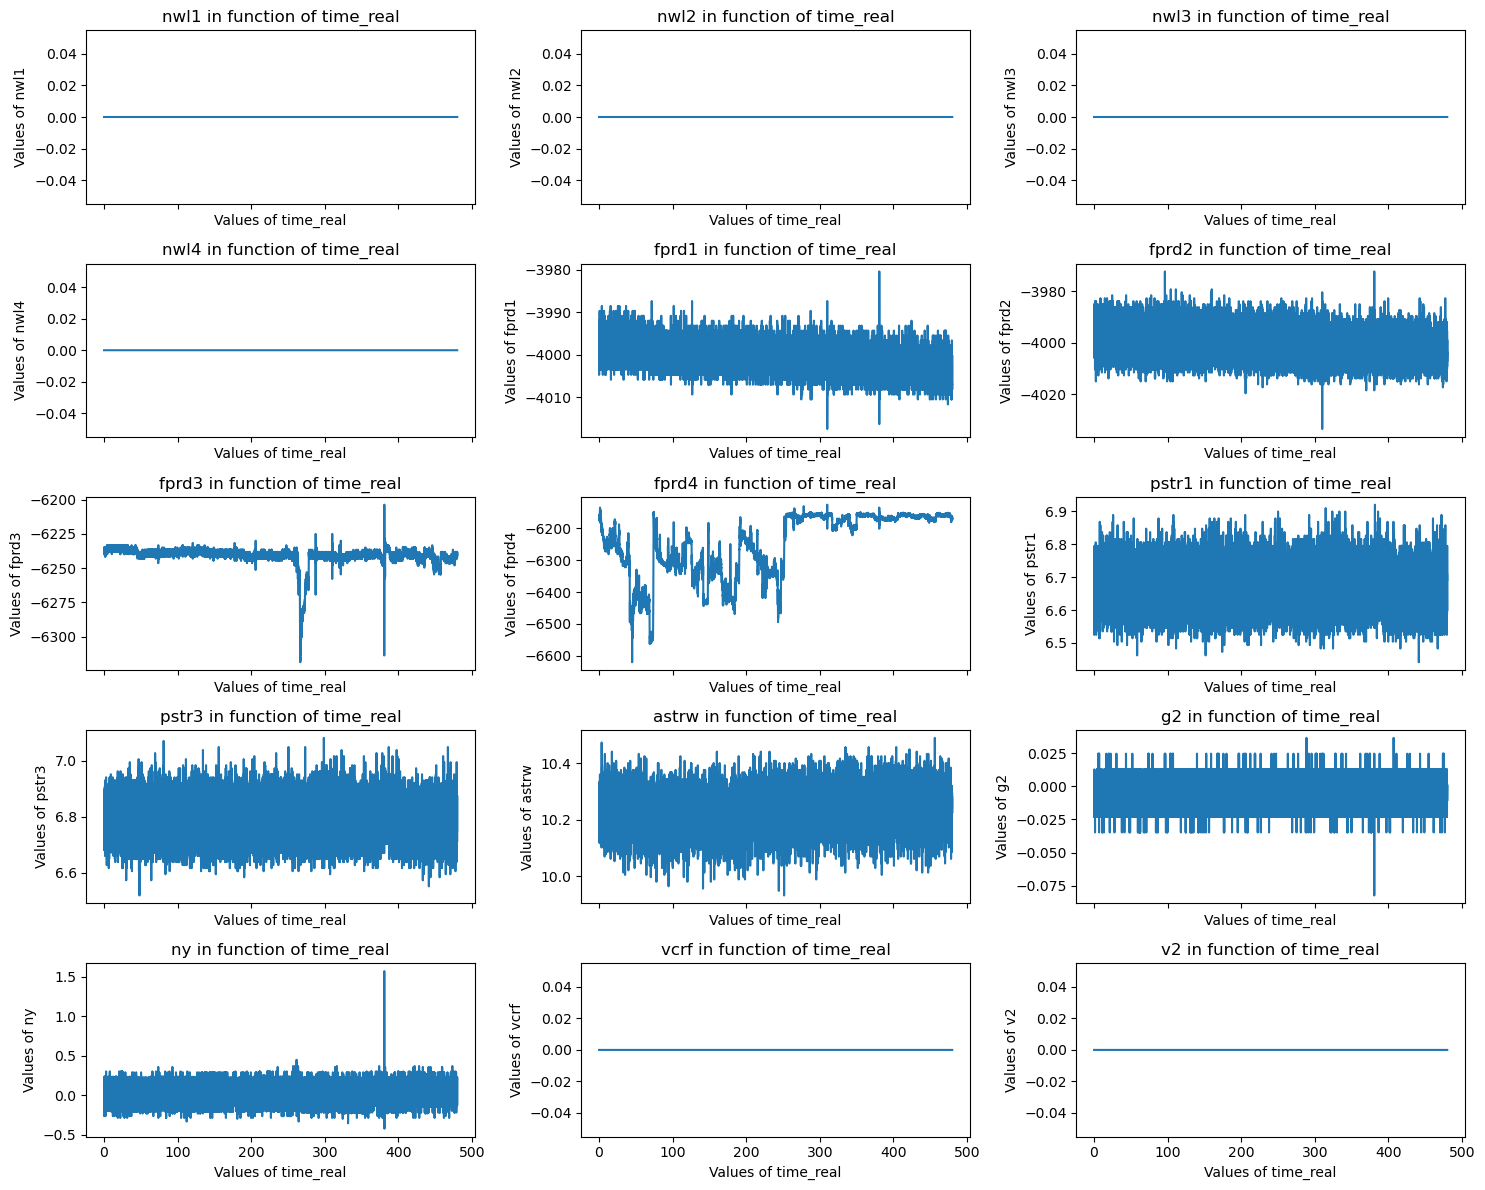

In [7]:
# Visualize a session from the first dataset (used for training)
df = data_dict[list_session[0]].copy()
df = preprocessing.clean_dataframe(df)
cols = df.columns[1:-1]
visualisation_plot(df, cols)

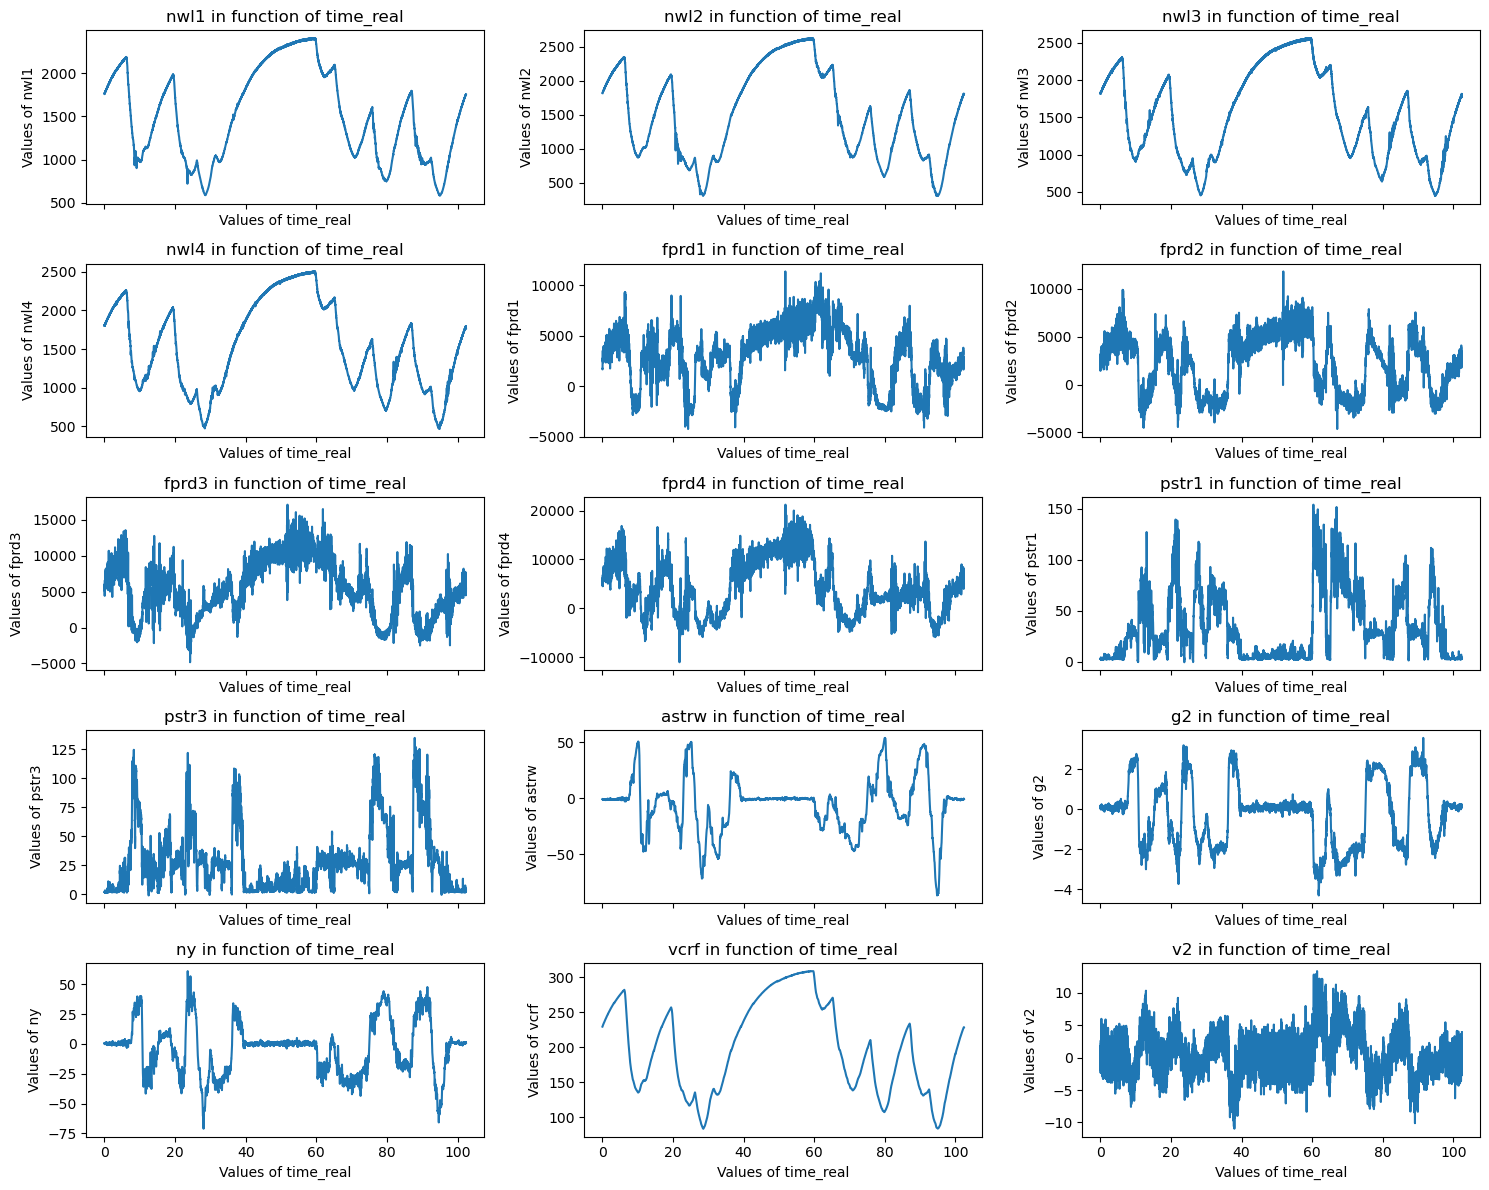

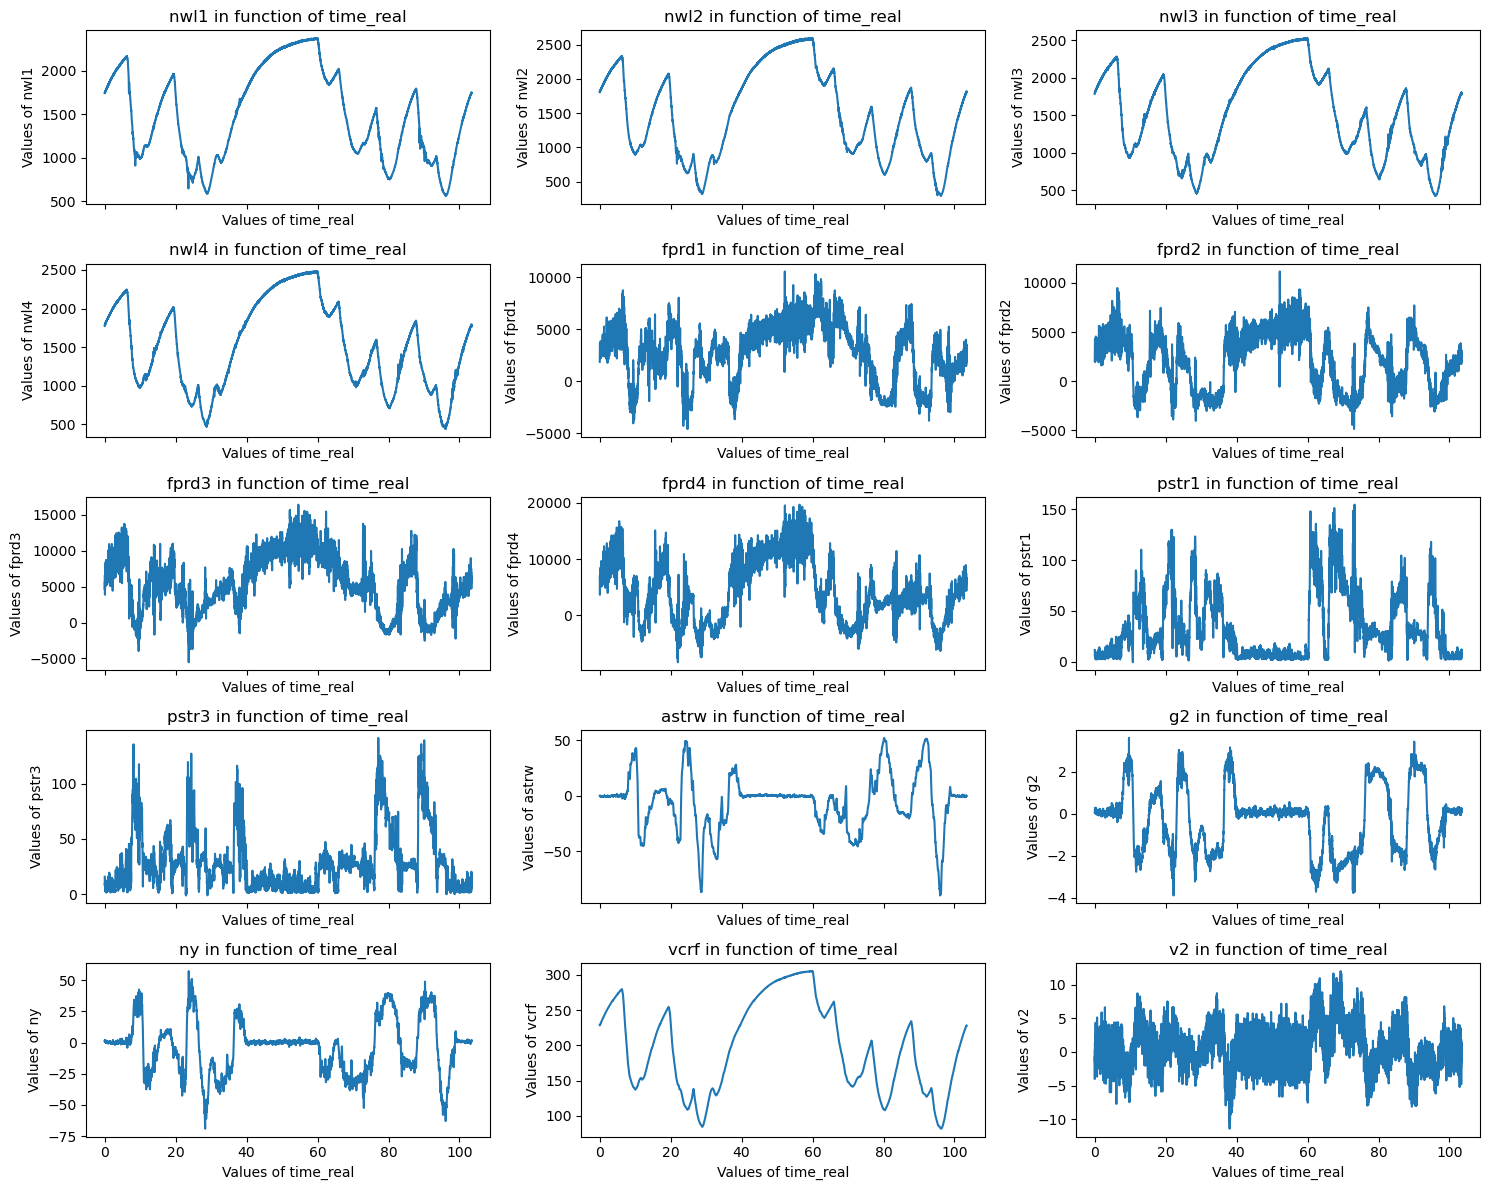

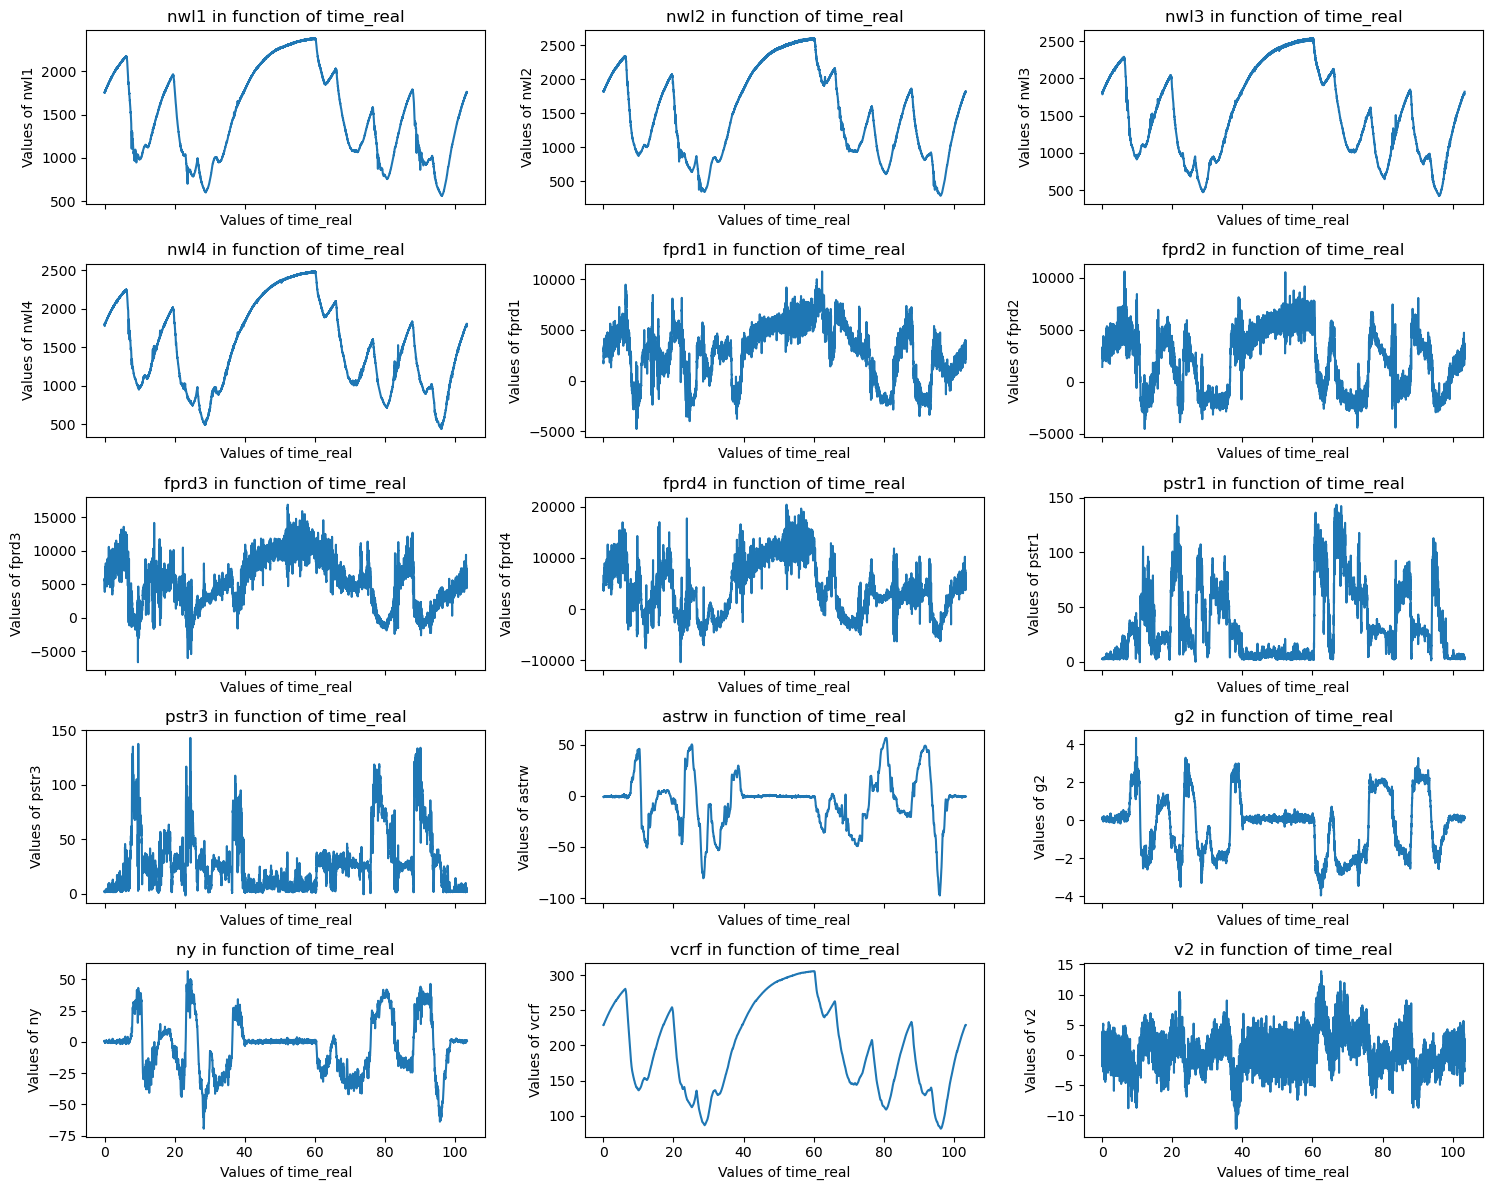

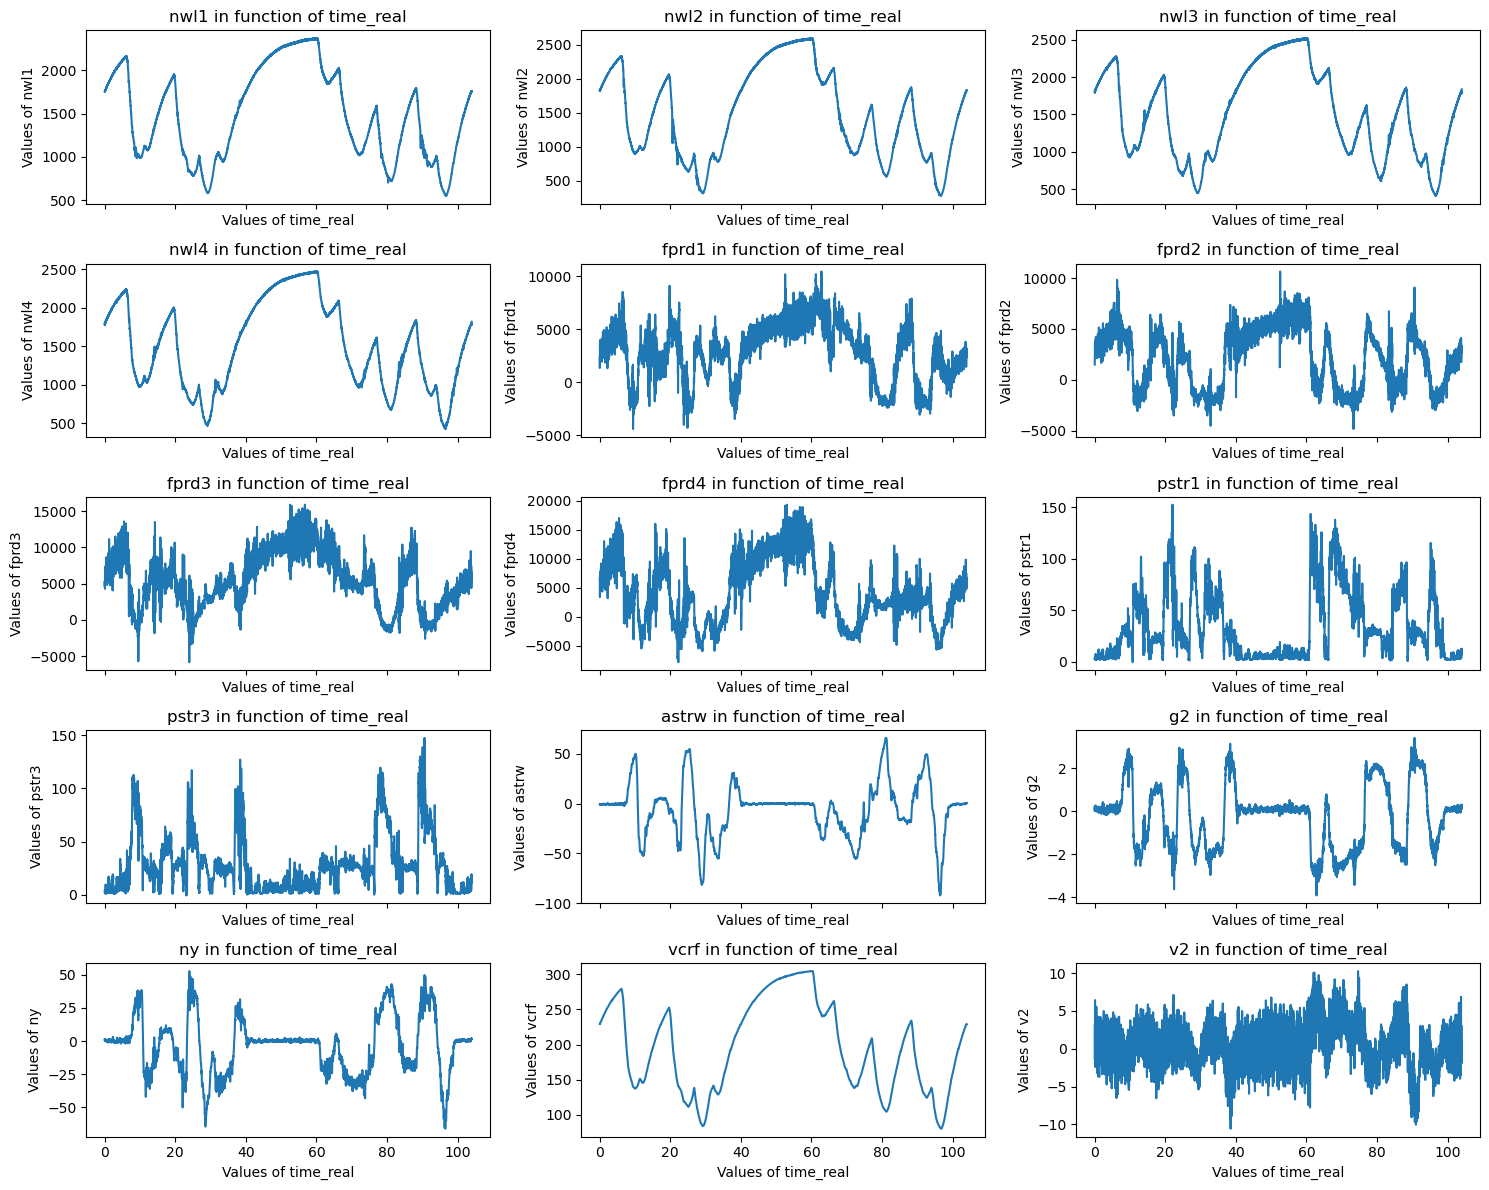

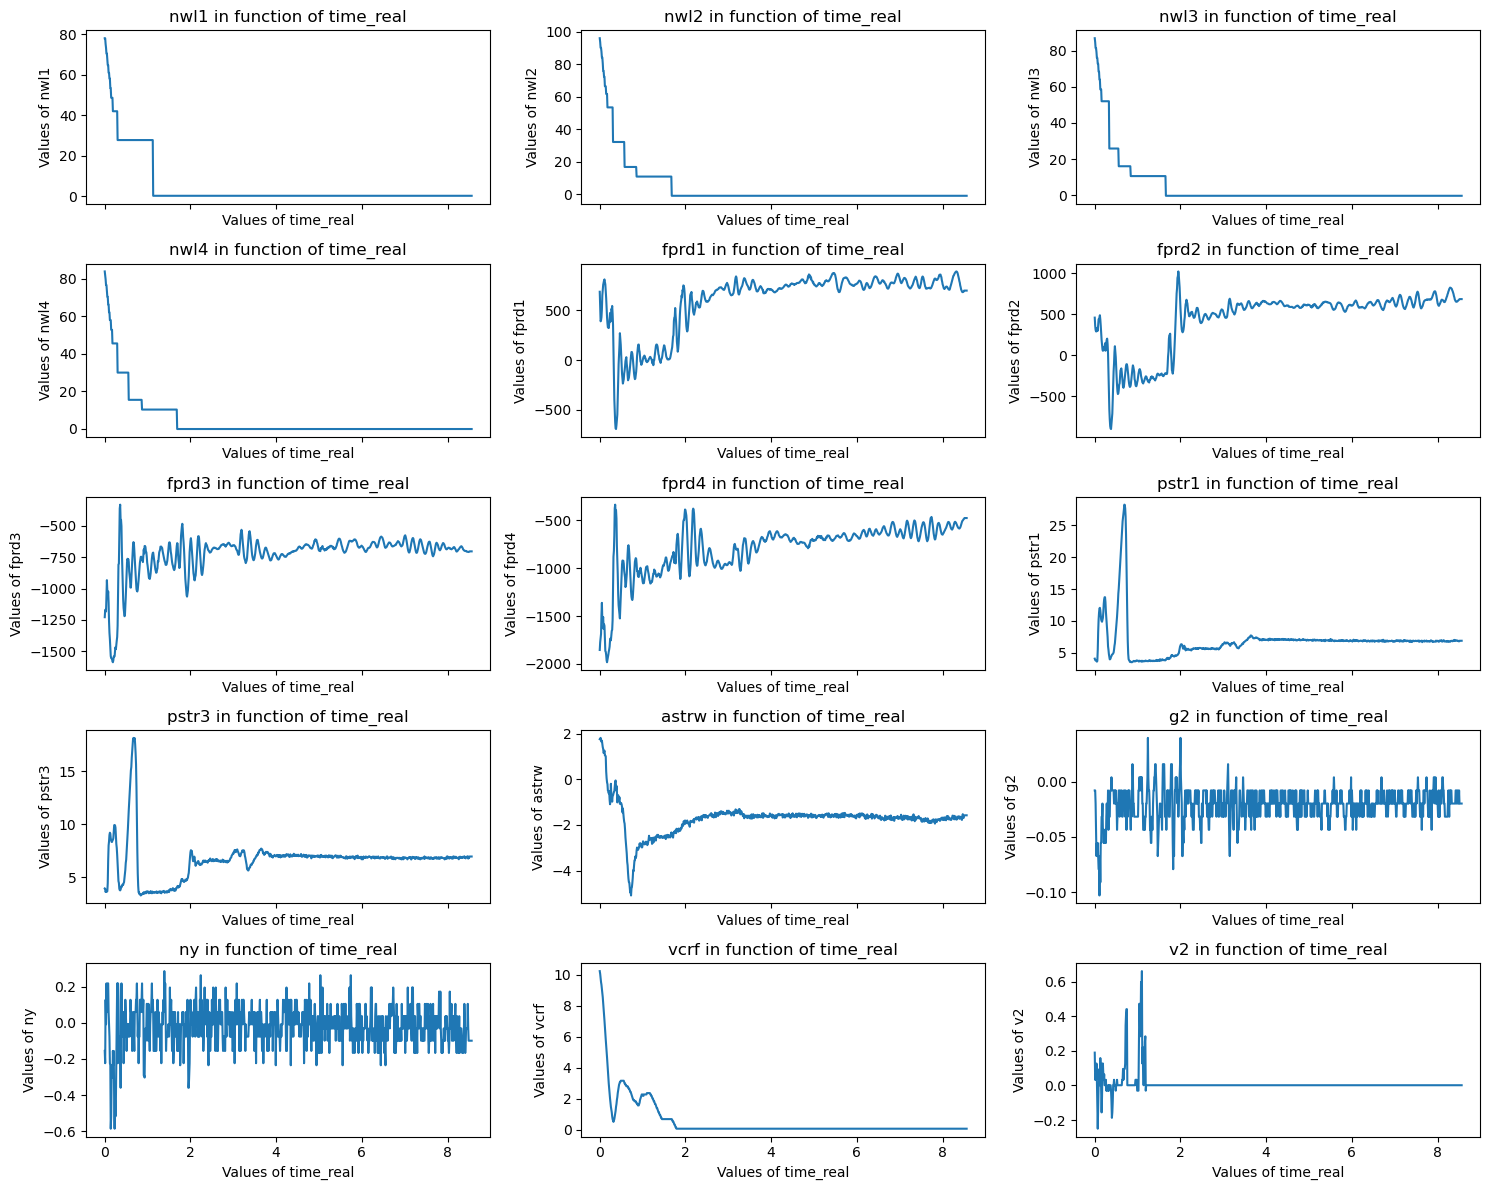

In [8]:
# Visualize a session from the second dataset (maybe used for testing)
for s in list_session2[:5]:
    df = data_dict2[s].copy()
    df = preprocessing.clean_dataframe(df)
    cols = df.columns[1:-1]
    visualisation_plot(df, cols)

# Anomaly detection

In [9]:
from joblib import dump, load
from tensorflow.keras.models import load_model

In [18]:
pca = load('./work01-data_exploration/models/pca_model.joblib')
if_pca = load('./work01-data_exploration/models/if_model.joblib')
dpca = load('./work01-data_exploration/models/dpca_model.joblib')
if_dy = load('./work01-data_exploration/models/if_dy_model.joblib')
scaler = load('./work01-data_exploration/models/scaler_model.joblib')
GRU = load_model('./work01-data_exploration/models/DNN_autoencoder.keras')
scaler_GRU = load('./work01-data_exploration/models/scaler_DNN_autoencoder.pkl')

c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## PCA and DPCA

c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


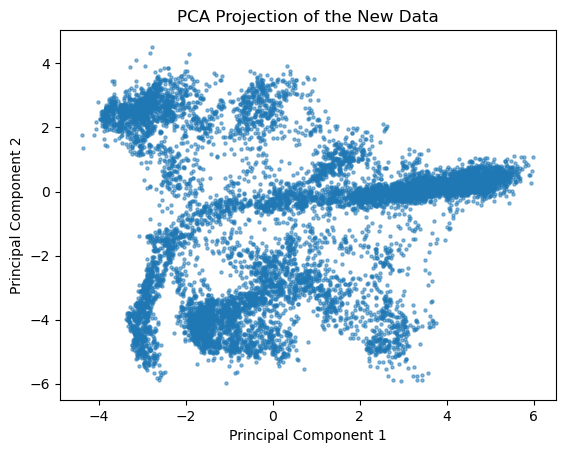

In [22]:
df = data_dict2[list_session2[0]].copy()
df = preprocessing.clean_dataframe(df)
df[cols] = scaler.transform(df[cols])
df_pca = pca.transform(df[cols])
df_pca[:,3:] = 0
reconstructed_pca = pca.inverse_transform(df_pca)
plt.scatter(df_pca[:, 0], df_pca[:, 1], alpha=0.5,s=5)
plt.title("PCA Projection of the New Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

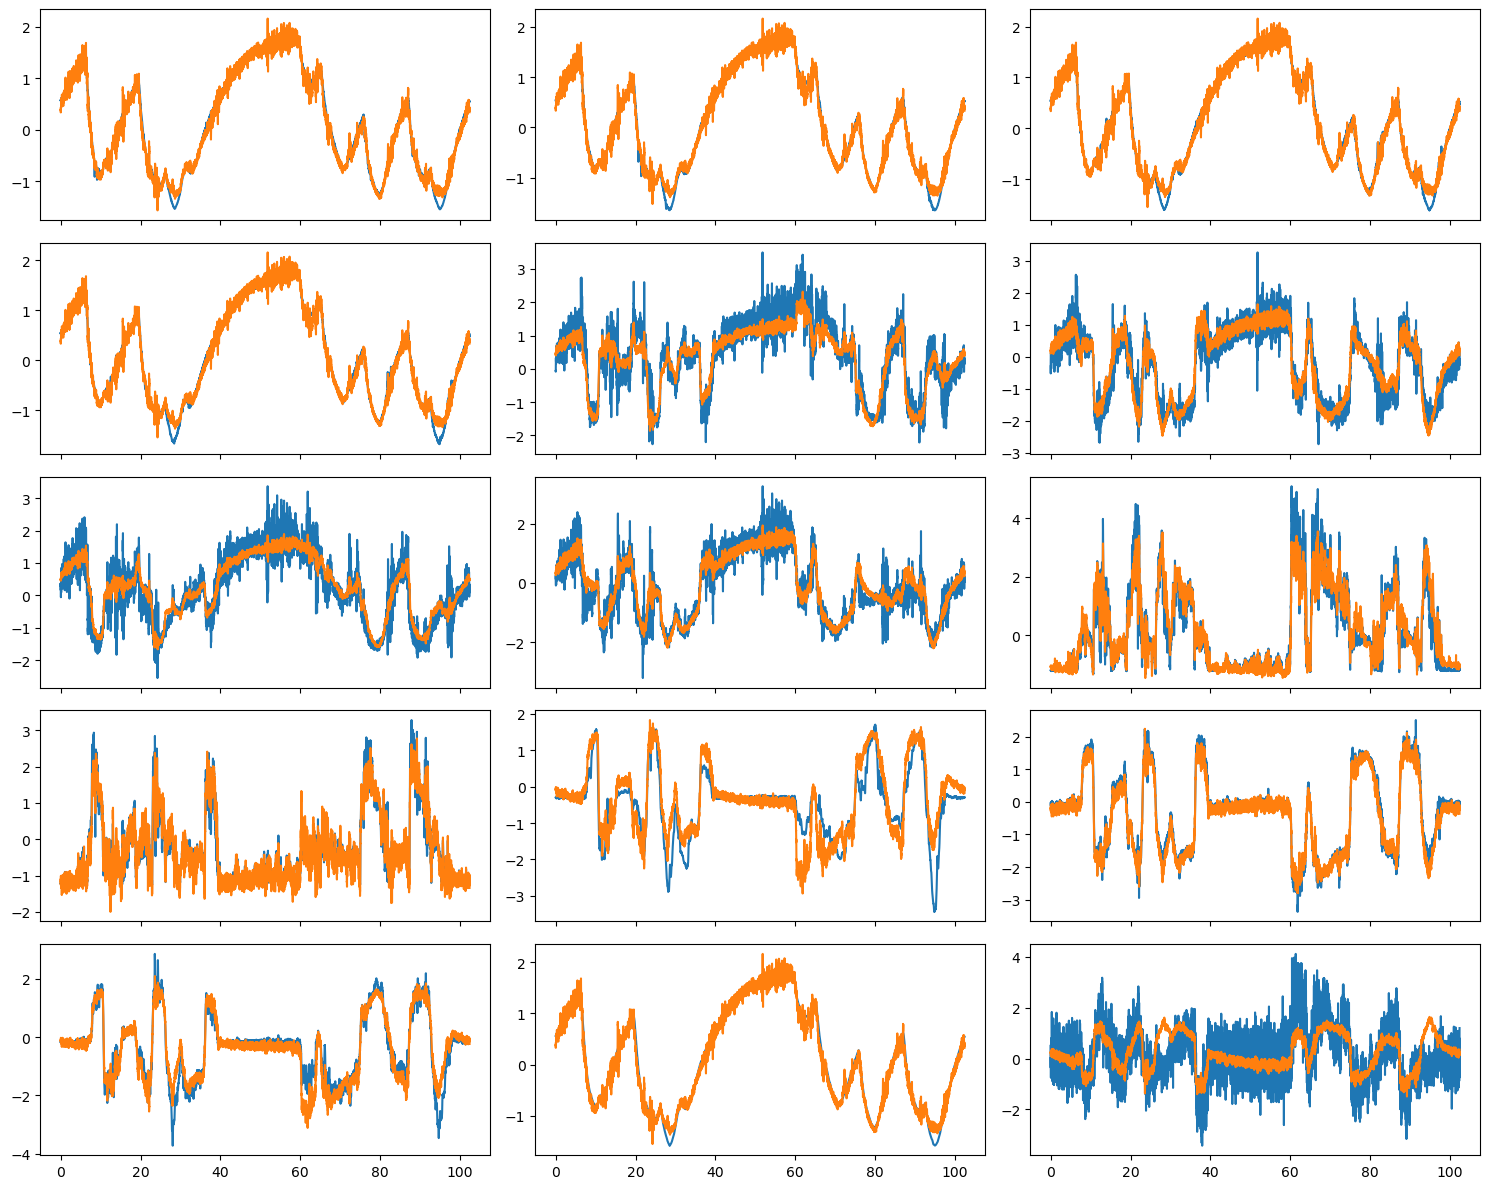

: 

In [ ]:
# Reconstruct the signals from PCA and visualize
cols = ['nwl1', 'nwl2', 'nwl3', 'nwl4', 'fprd1', 'fprd2', 'fprd3',
       'fprd4', 'pstr1', 'pstr3', 'astrw', 'g2', 'ny', 'vcrf', 'v2']
visualisation_plot_nparray(df, reconstructed_pca, cols)

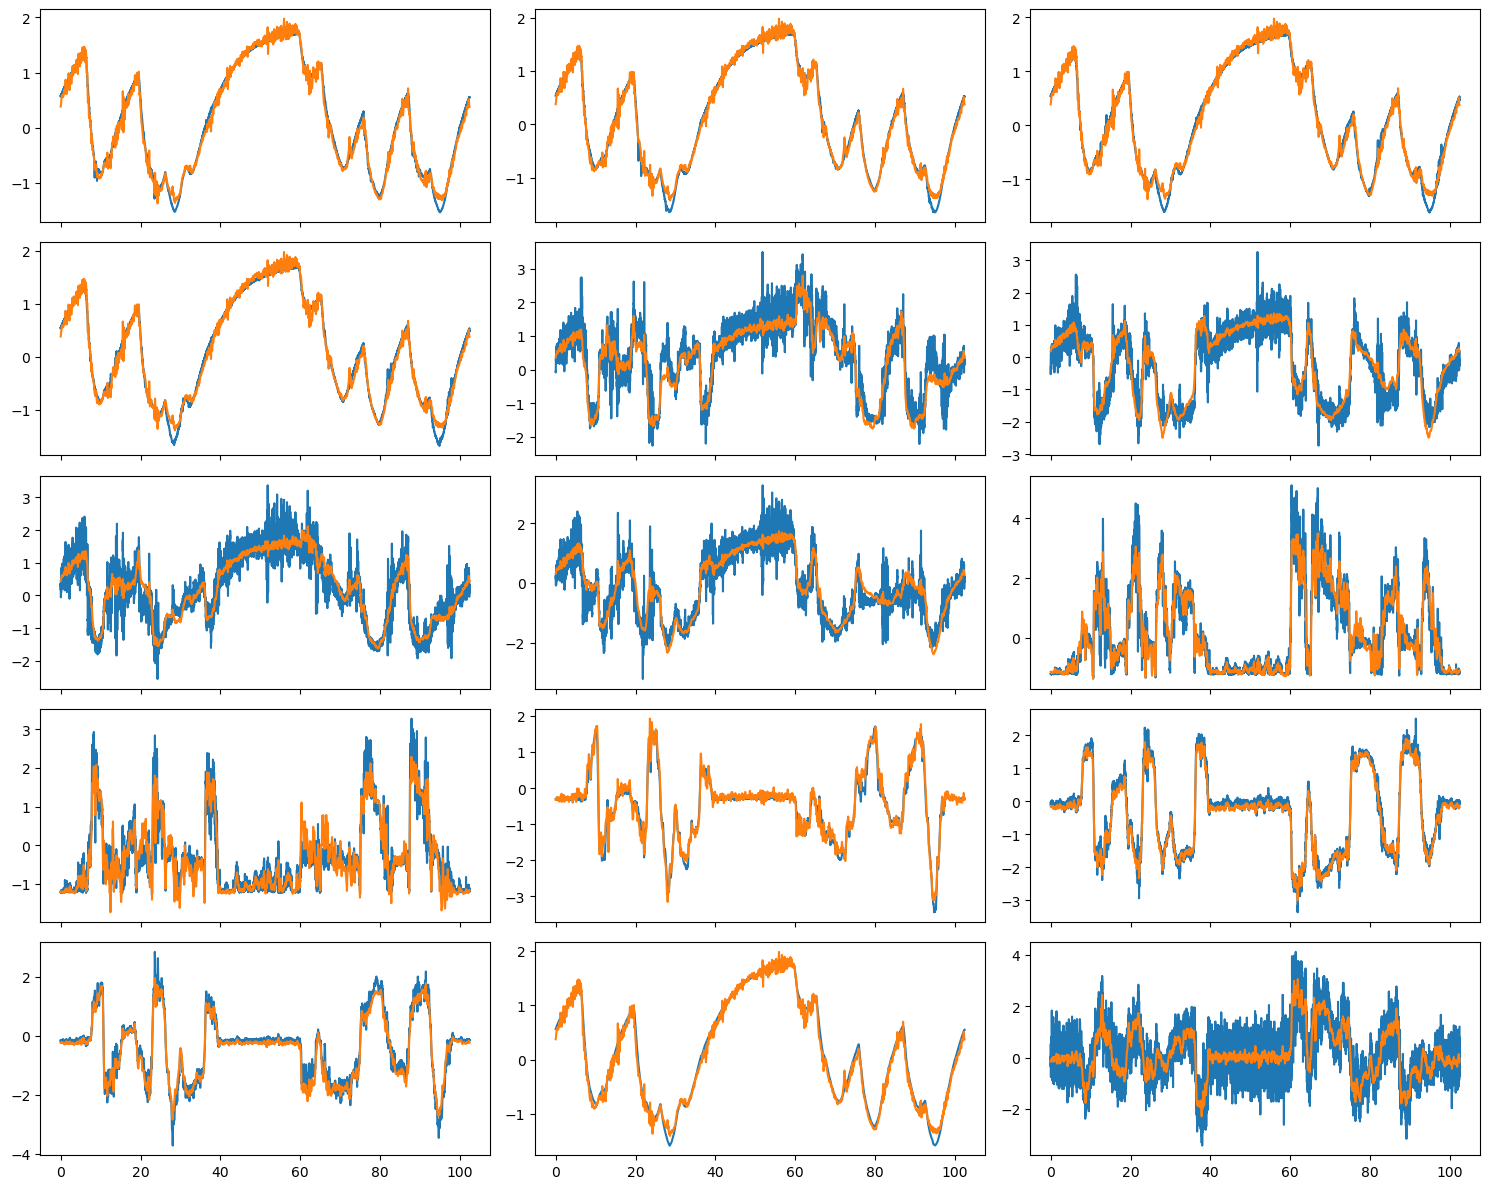

In [23]:
# Reconstruct the signals from DPCA and visualize
from anomaly_detection.dimension_reduction.pca import dynamic_augmentation, inverse_dynamic_augmentation, lag_augmented
lag_aug = lag_augmented(8, df[cols].shape[1])
df_augmented = lag_aug.transform(df[cols].values)
df_dpca = dpca.transform(df_augmented)
df_dpca[:,4:] = 0
reconstructed_dpca = dpca.inverse_transform(df_dpca)
reconstructed_dpca = lag_aug.inverse_transform(reconstructed_dpca)
visualisation_plot_nparray(df, reconstructed_dpca, cols)

## Anomaly detection by PCA and DPCA

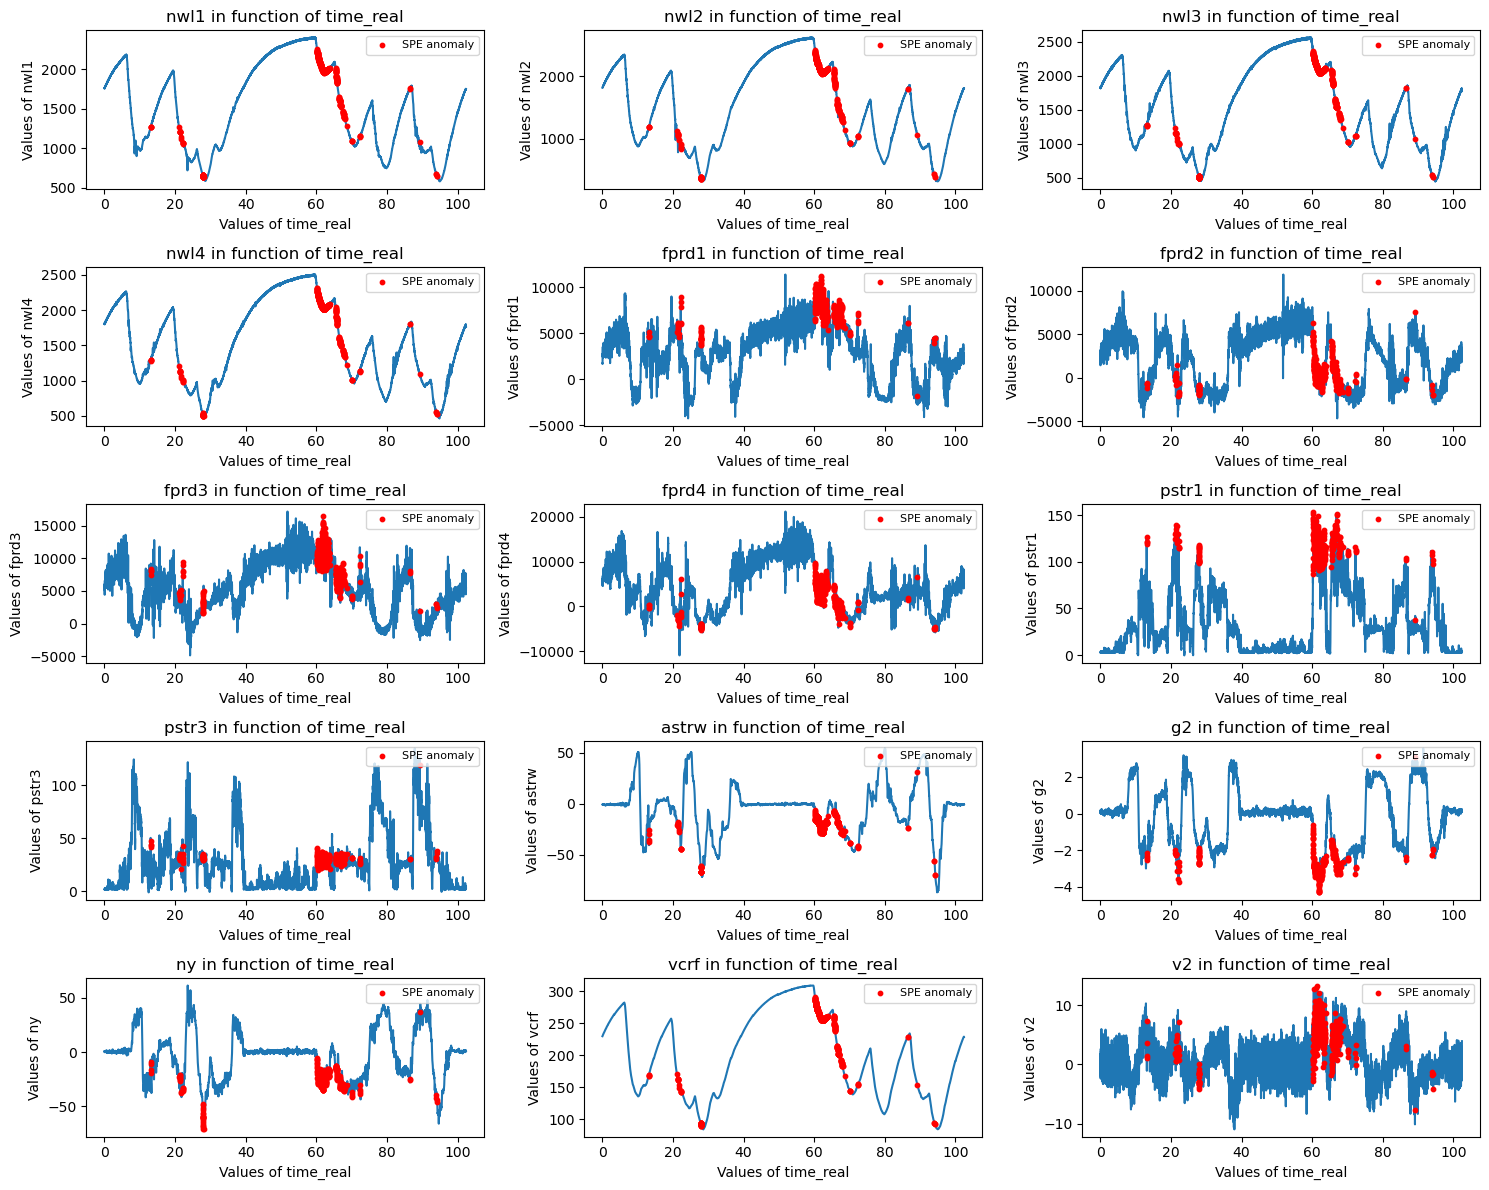

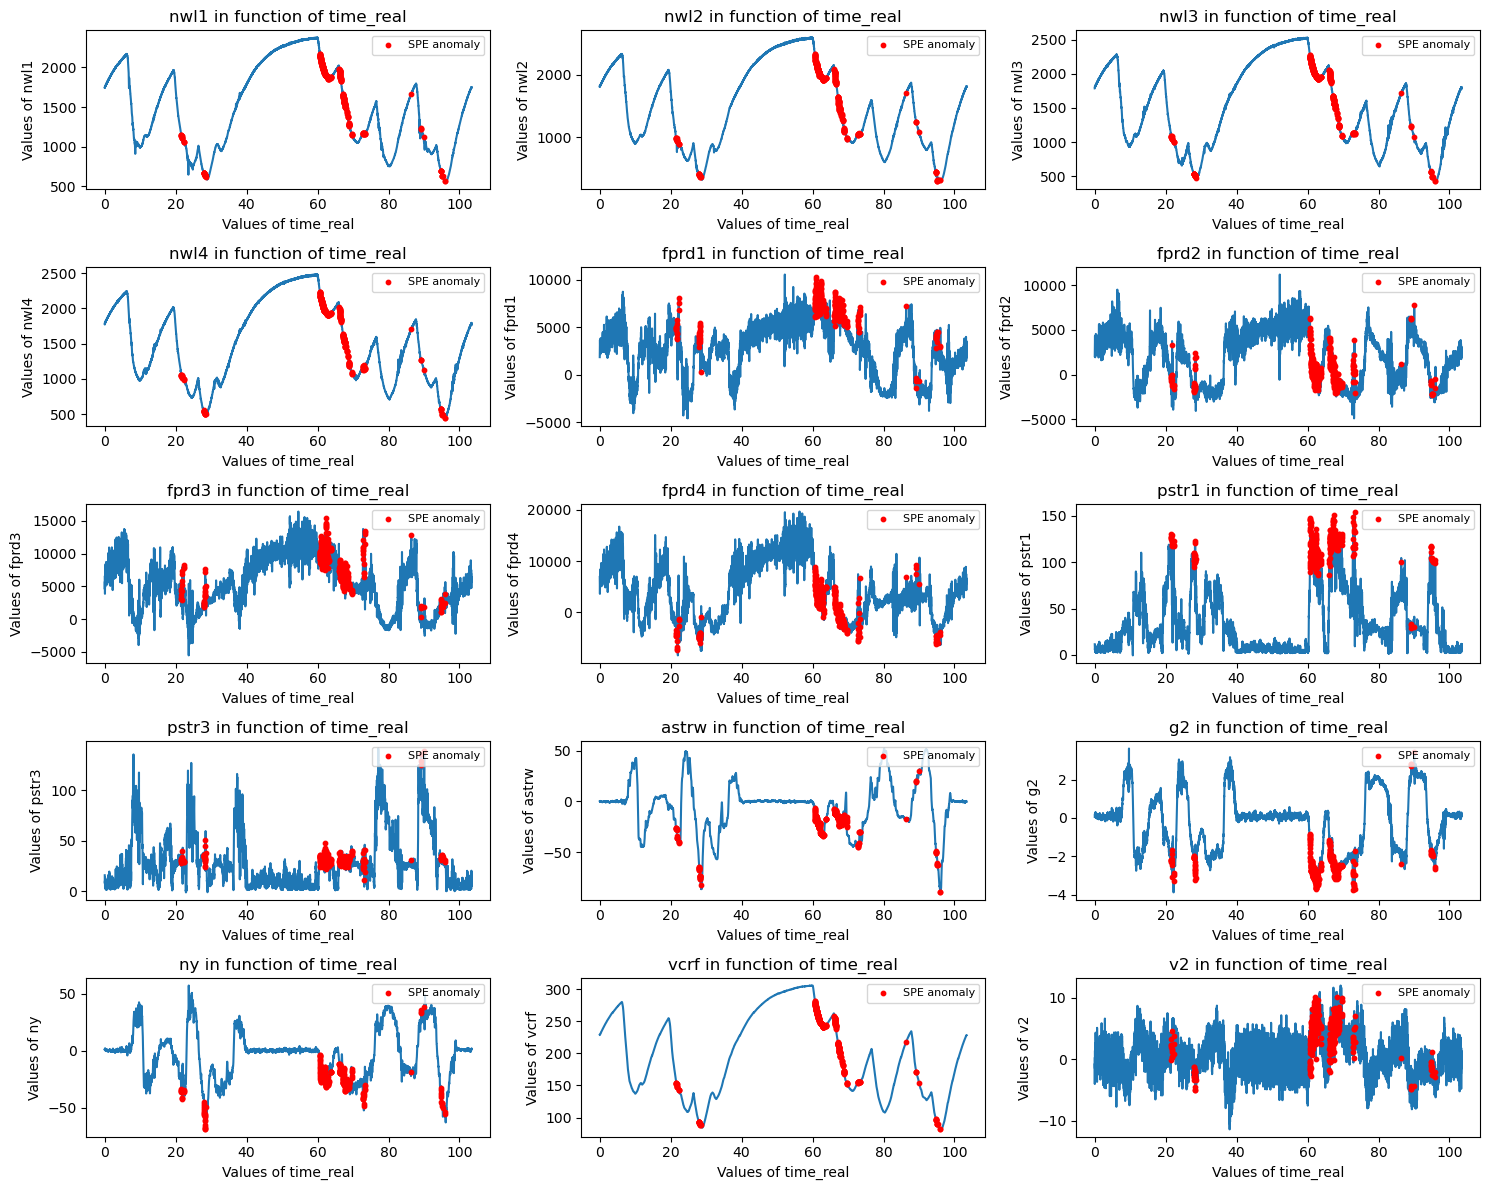

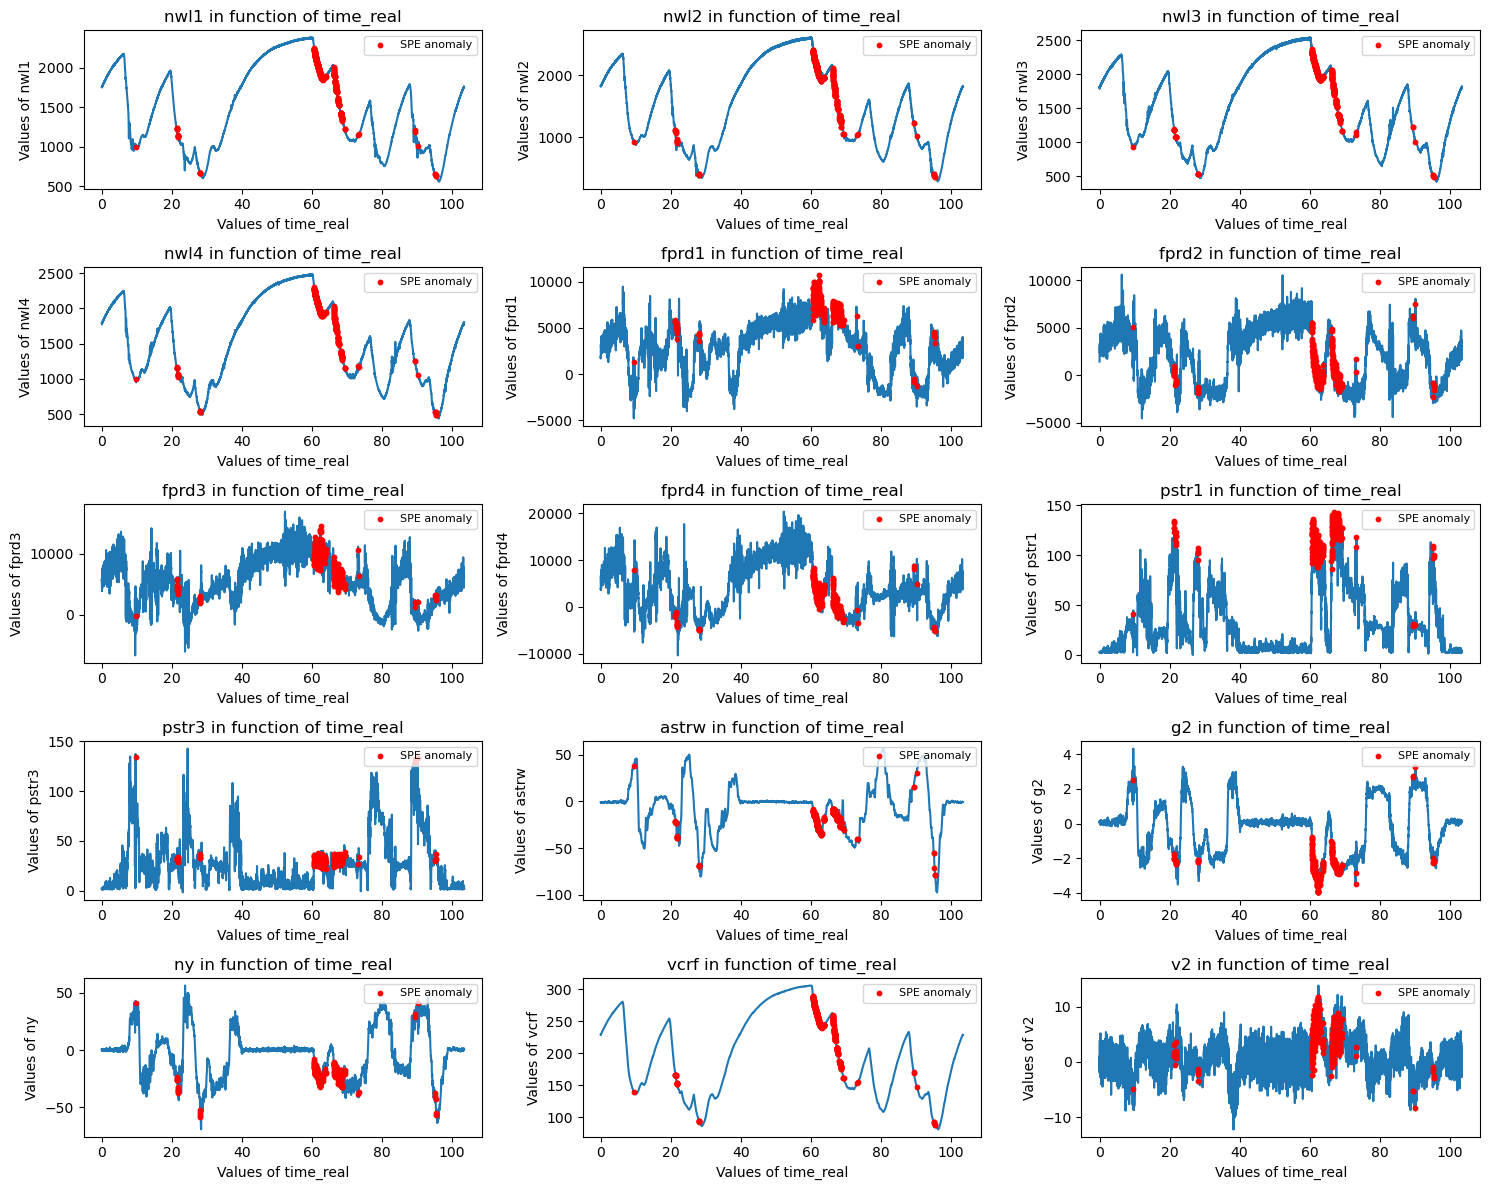

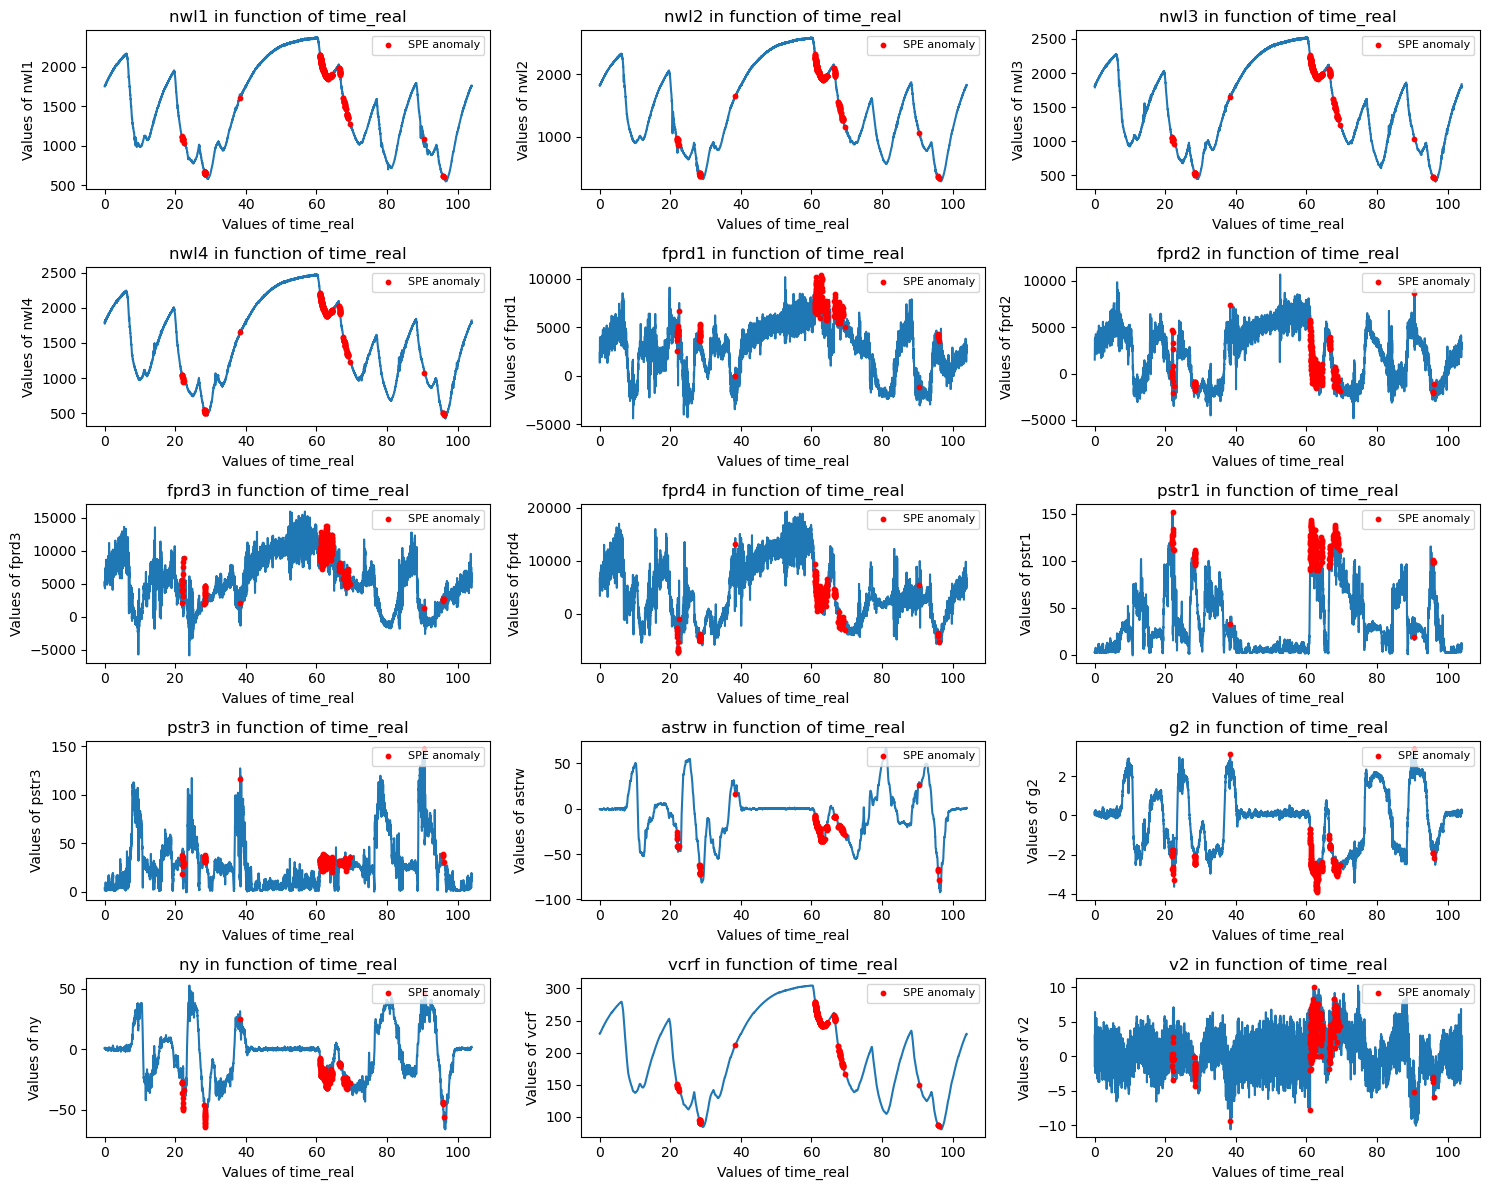

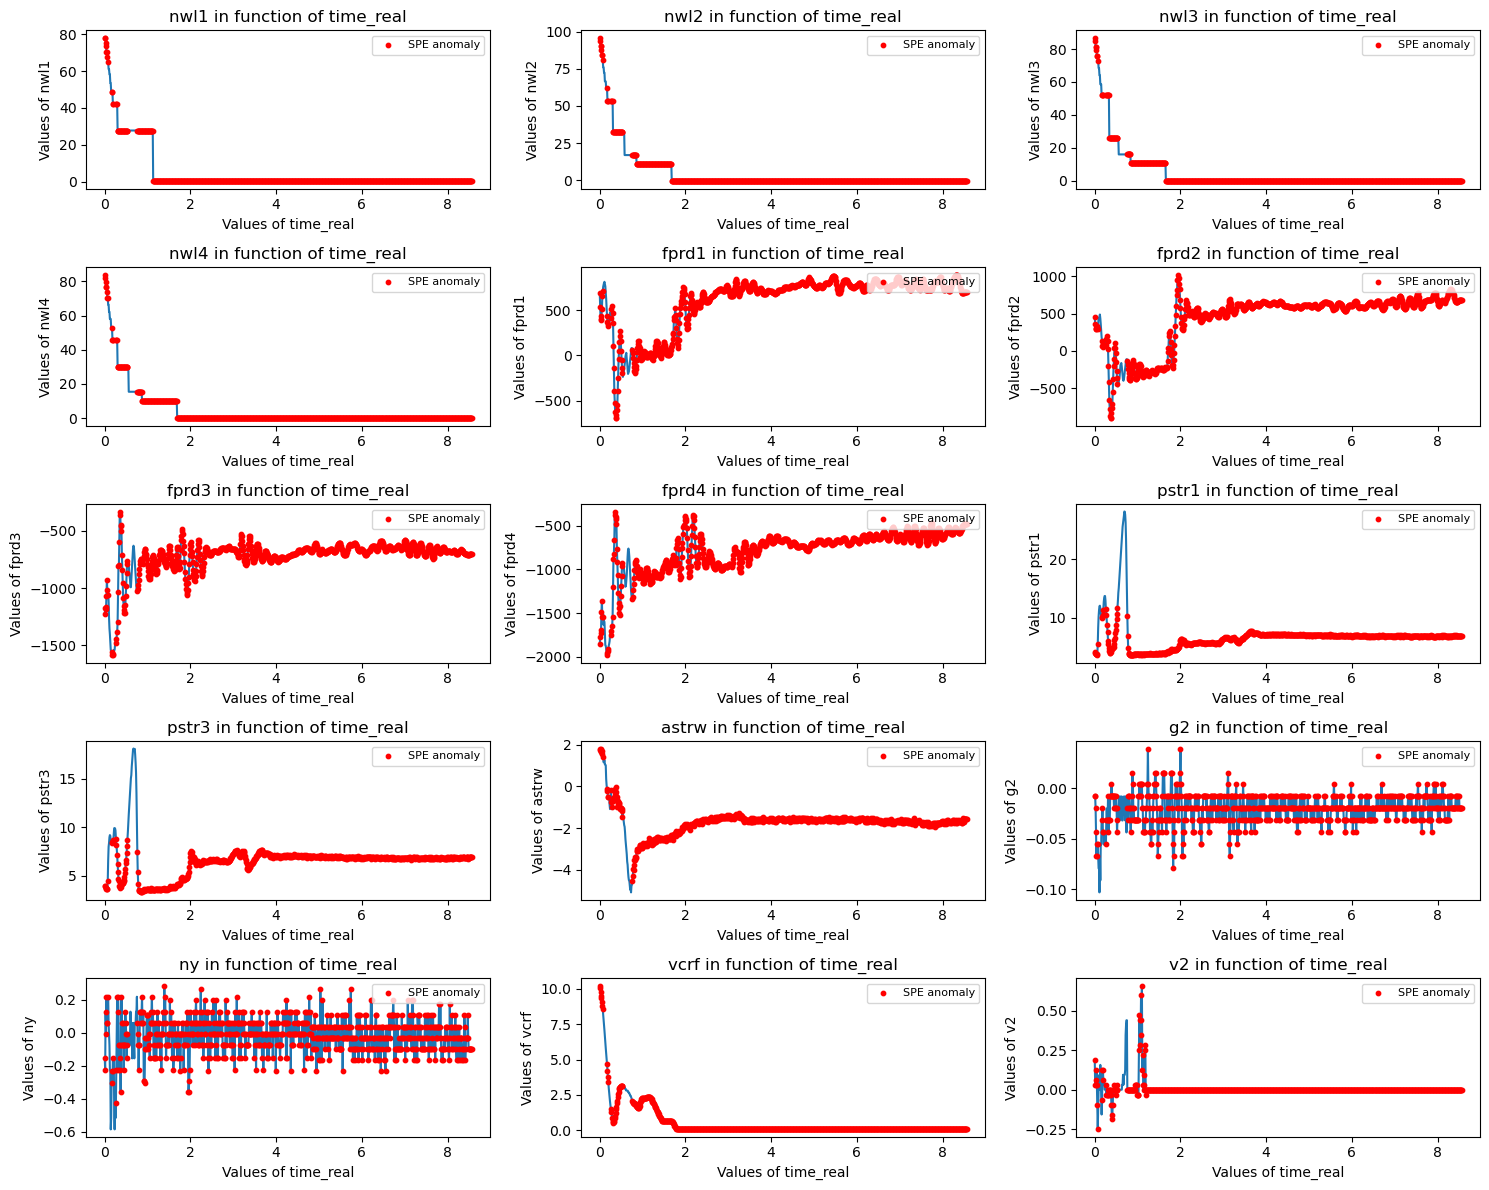

In [25]:
for s in list_session2[:5]:
    df = data_dict2[s].copy()
    df = preprocessing.clean_dataframe(df)   
    visualisation_anomalies(df, pca_anomaly_detection(df, cols, pca, scaler, d=3, method="IF", clf_IF=if_pca), 
                        cols, method="pca")

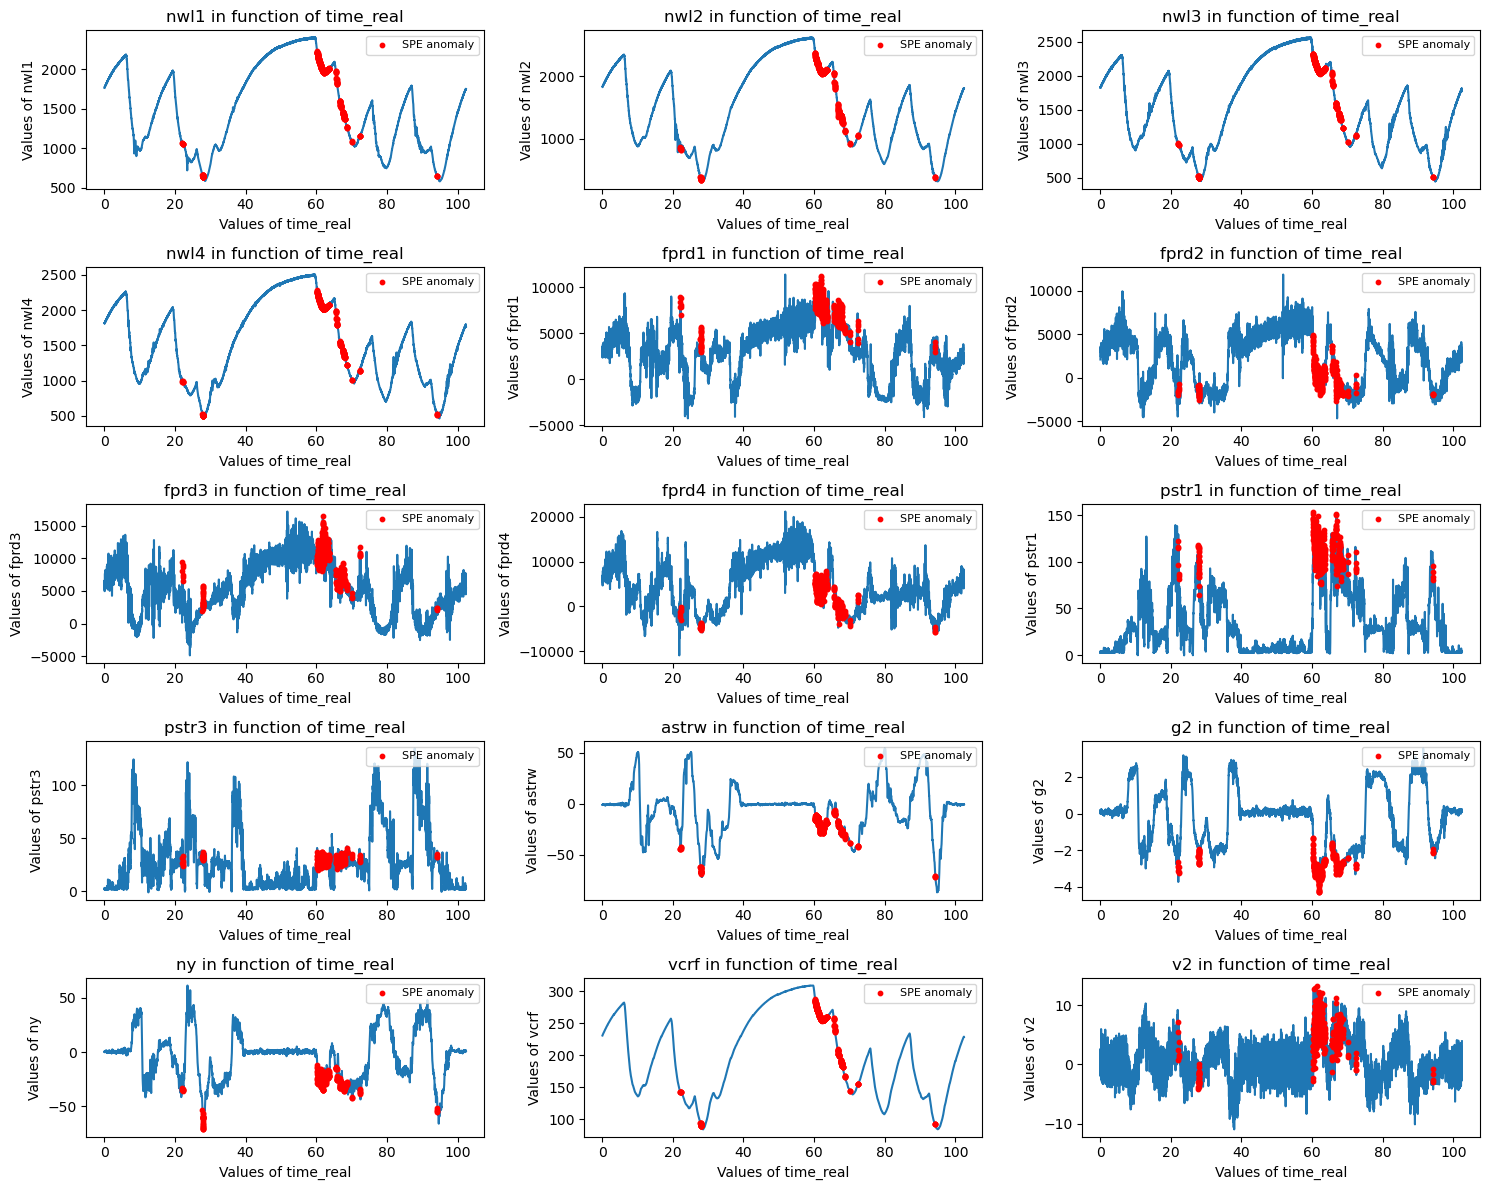

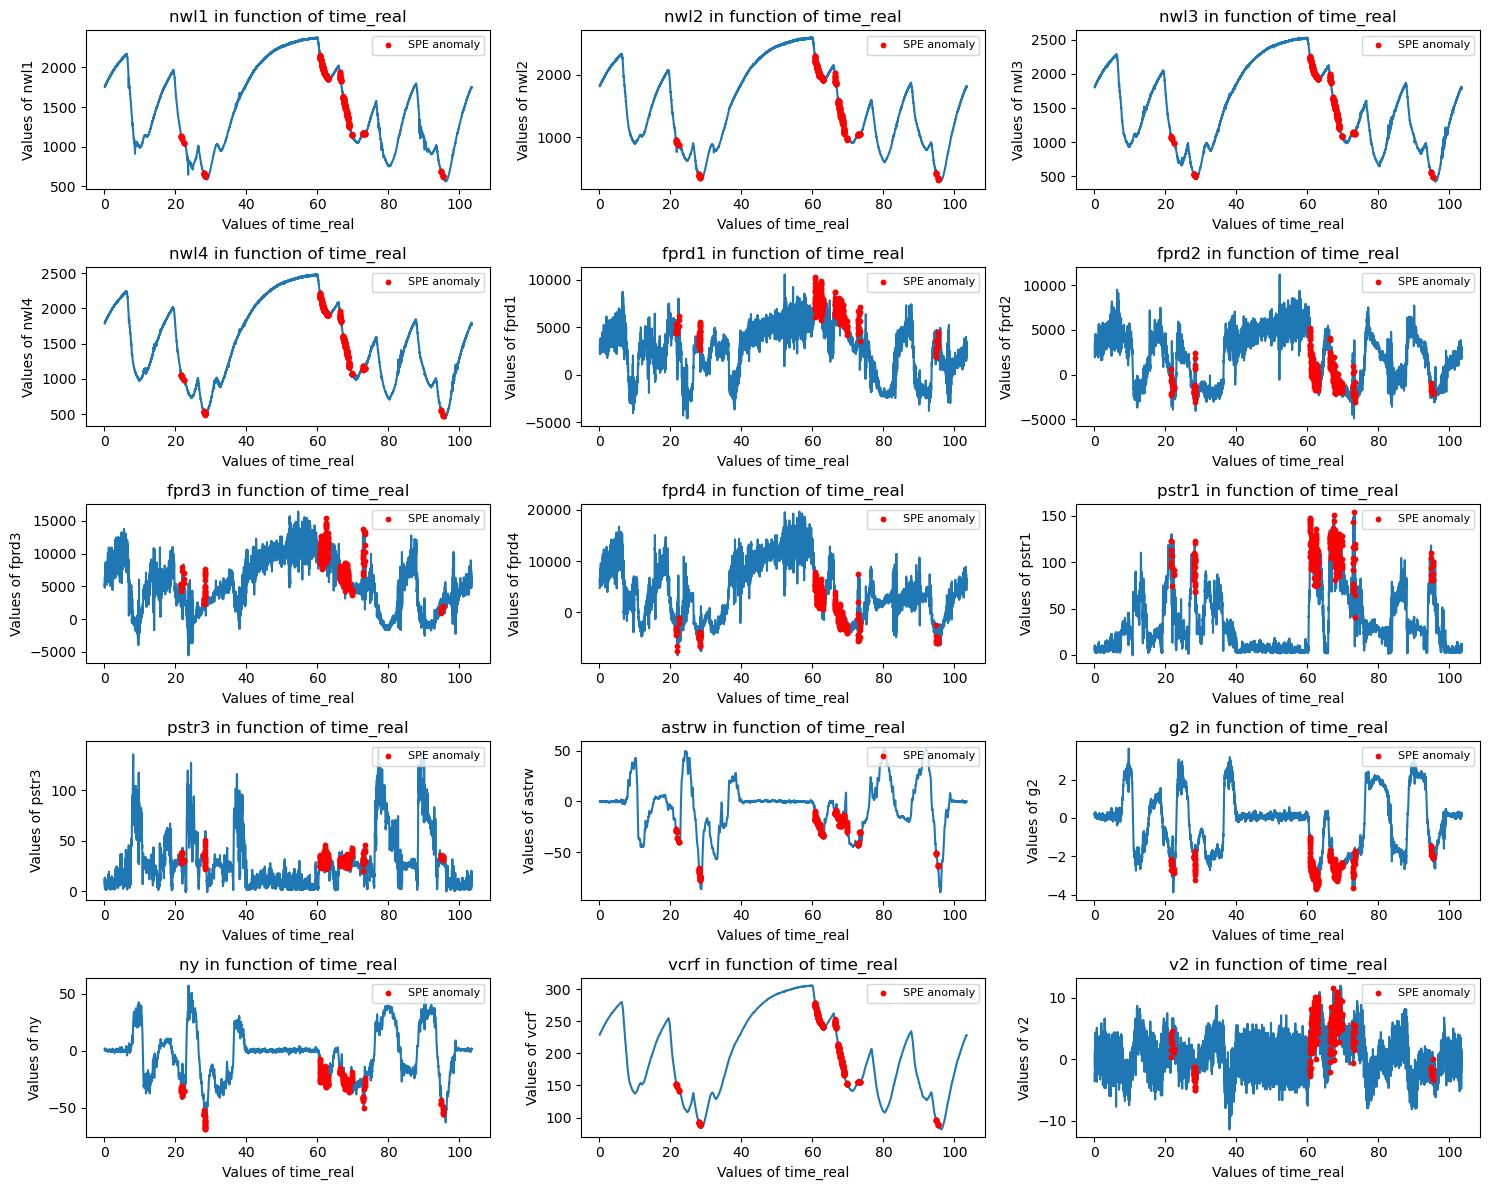

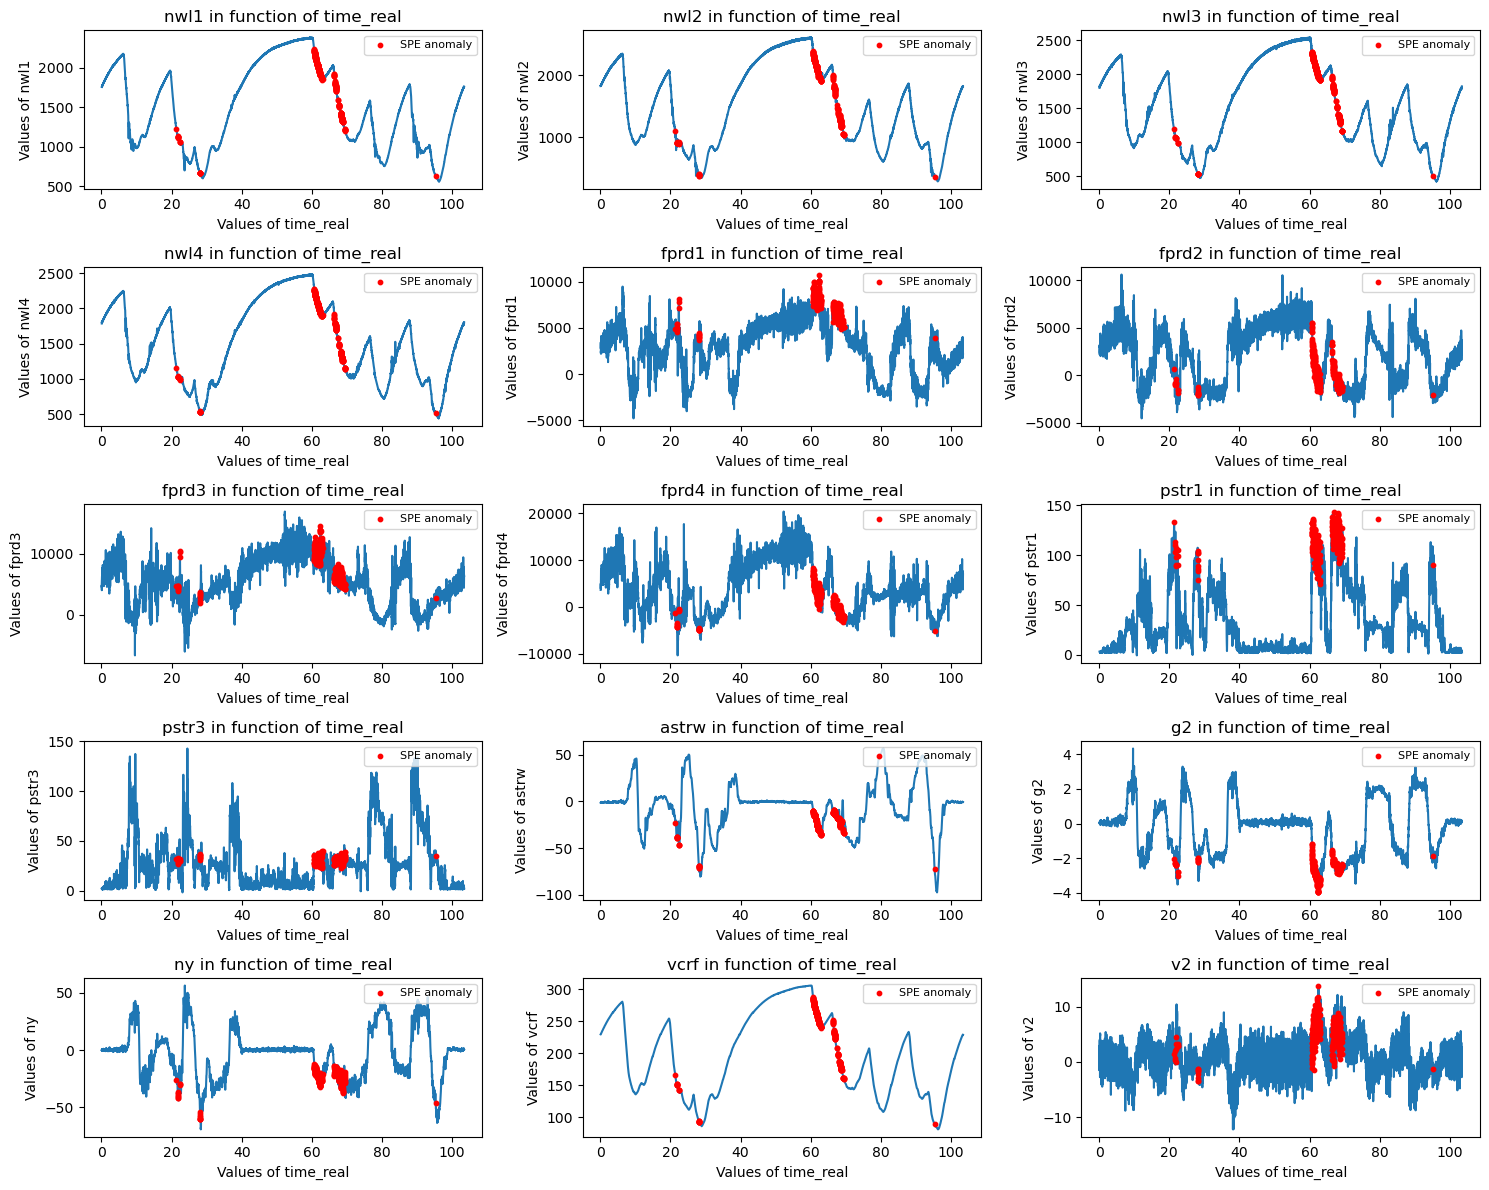

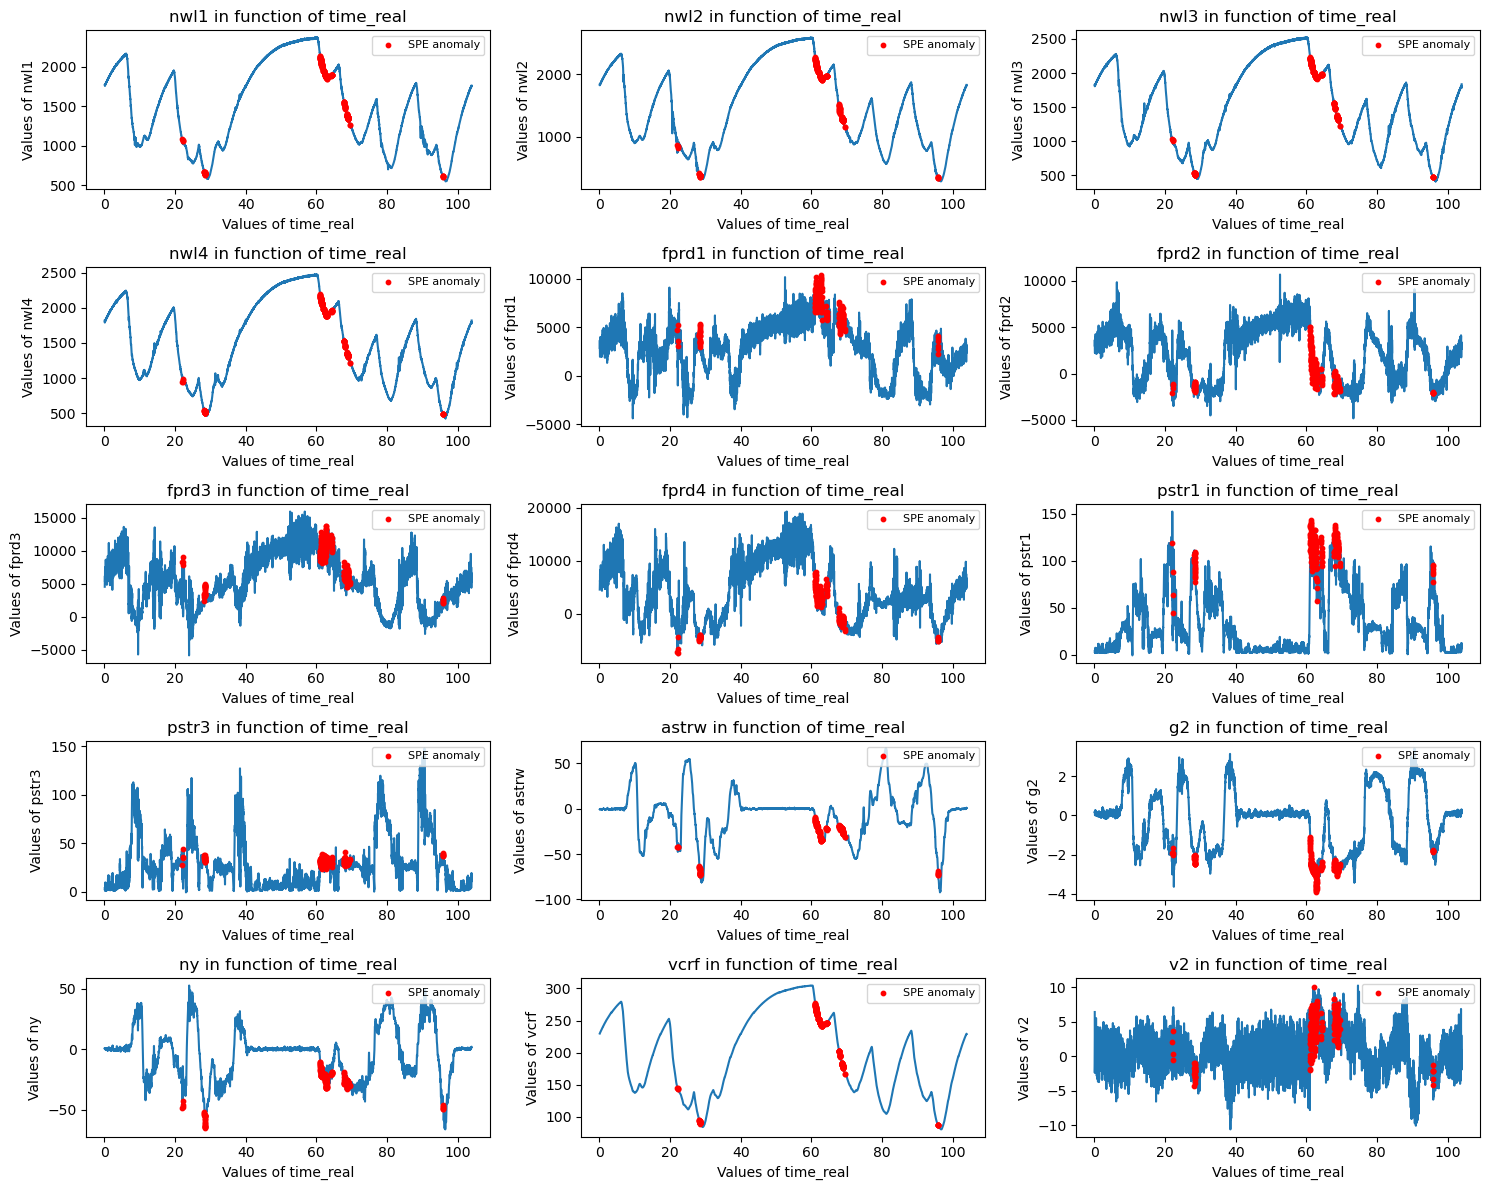

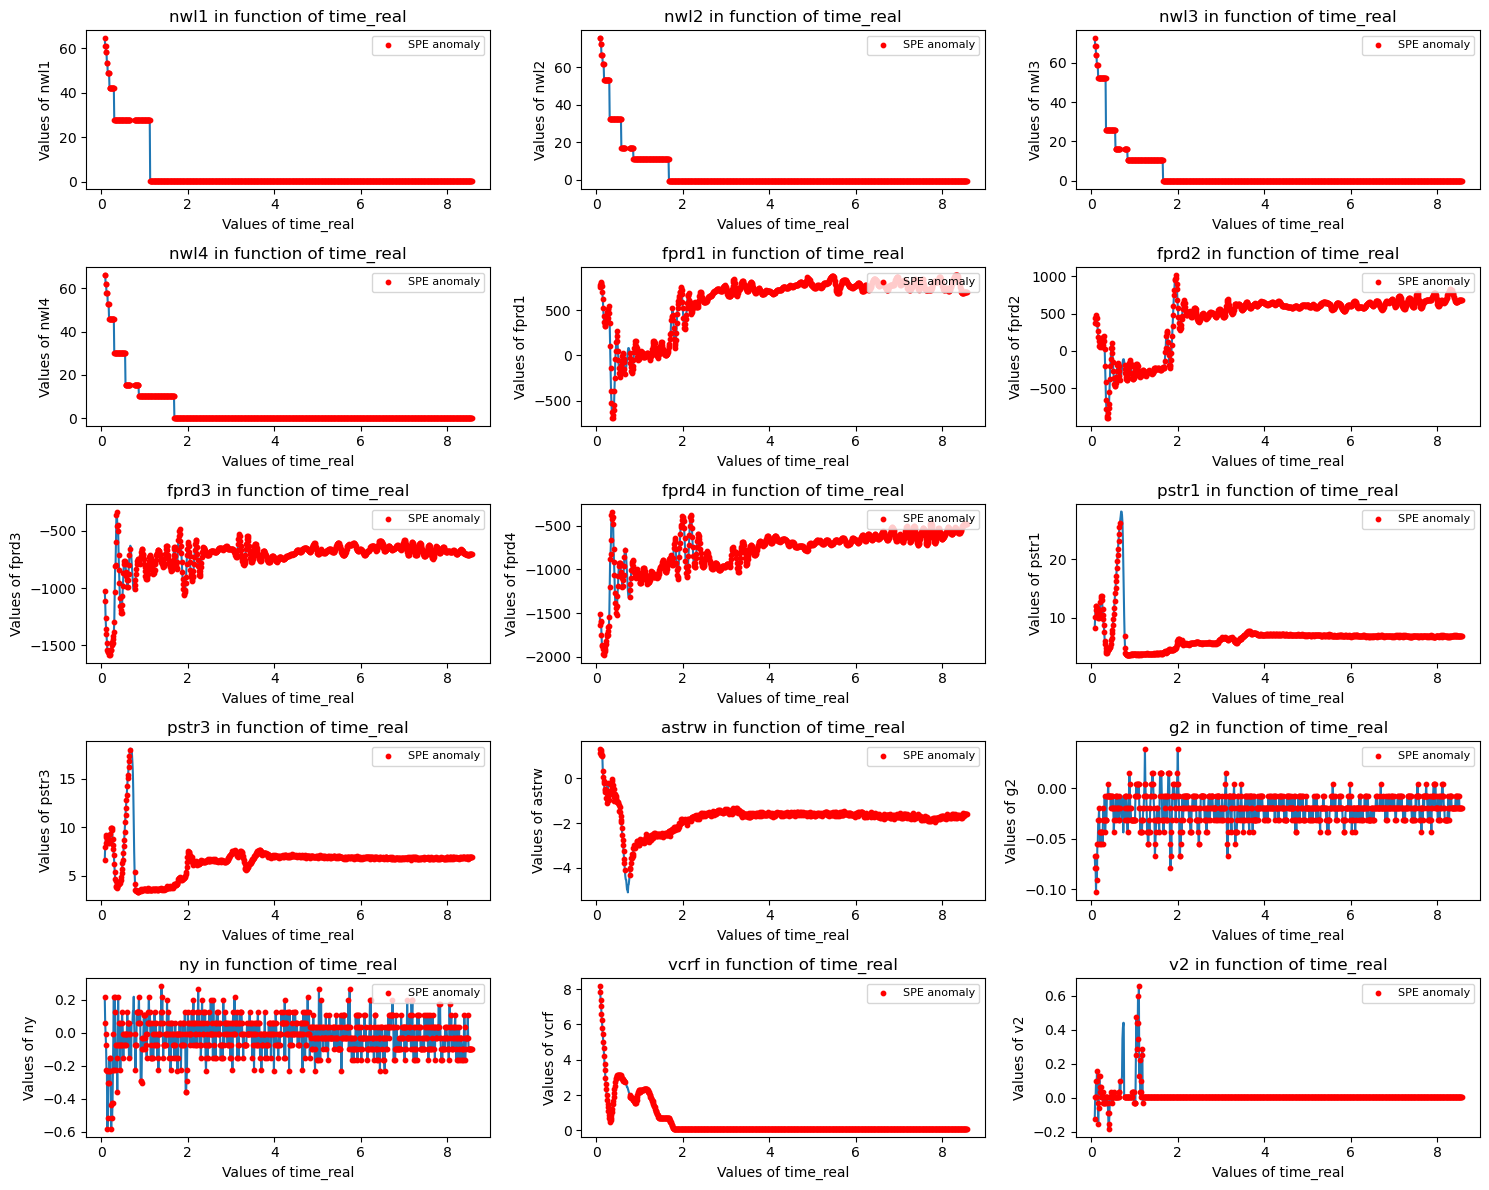

: 

: 

In [ ]:
for s in list_session2[:5]:
    df = data_dict2[s].copy()
    df = preprocessing.clean_dataframe(df)
    visualisation_anomalies(df, dpca_anomaly_detection(df, cols, dpca, scaler, d=3, method="IF", clf_IF=if_dy), 
                            cols, method="dpca")

## GRU

In [26]:
def create_sequences(df_input, features_list, time_steps):

    values = df_input[features_list].values
    sequences_list = []
    for i in range(len(values) - time_steps + 1):
        seq=values[i : (i + time_steps),:]
        sequences_list.append(seq)
    return np.array(sequences_list)

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step


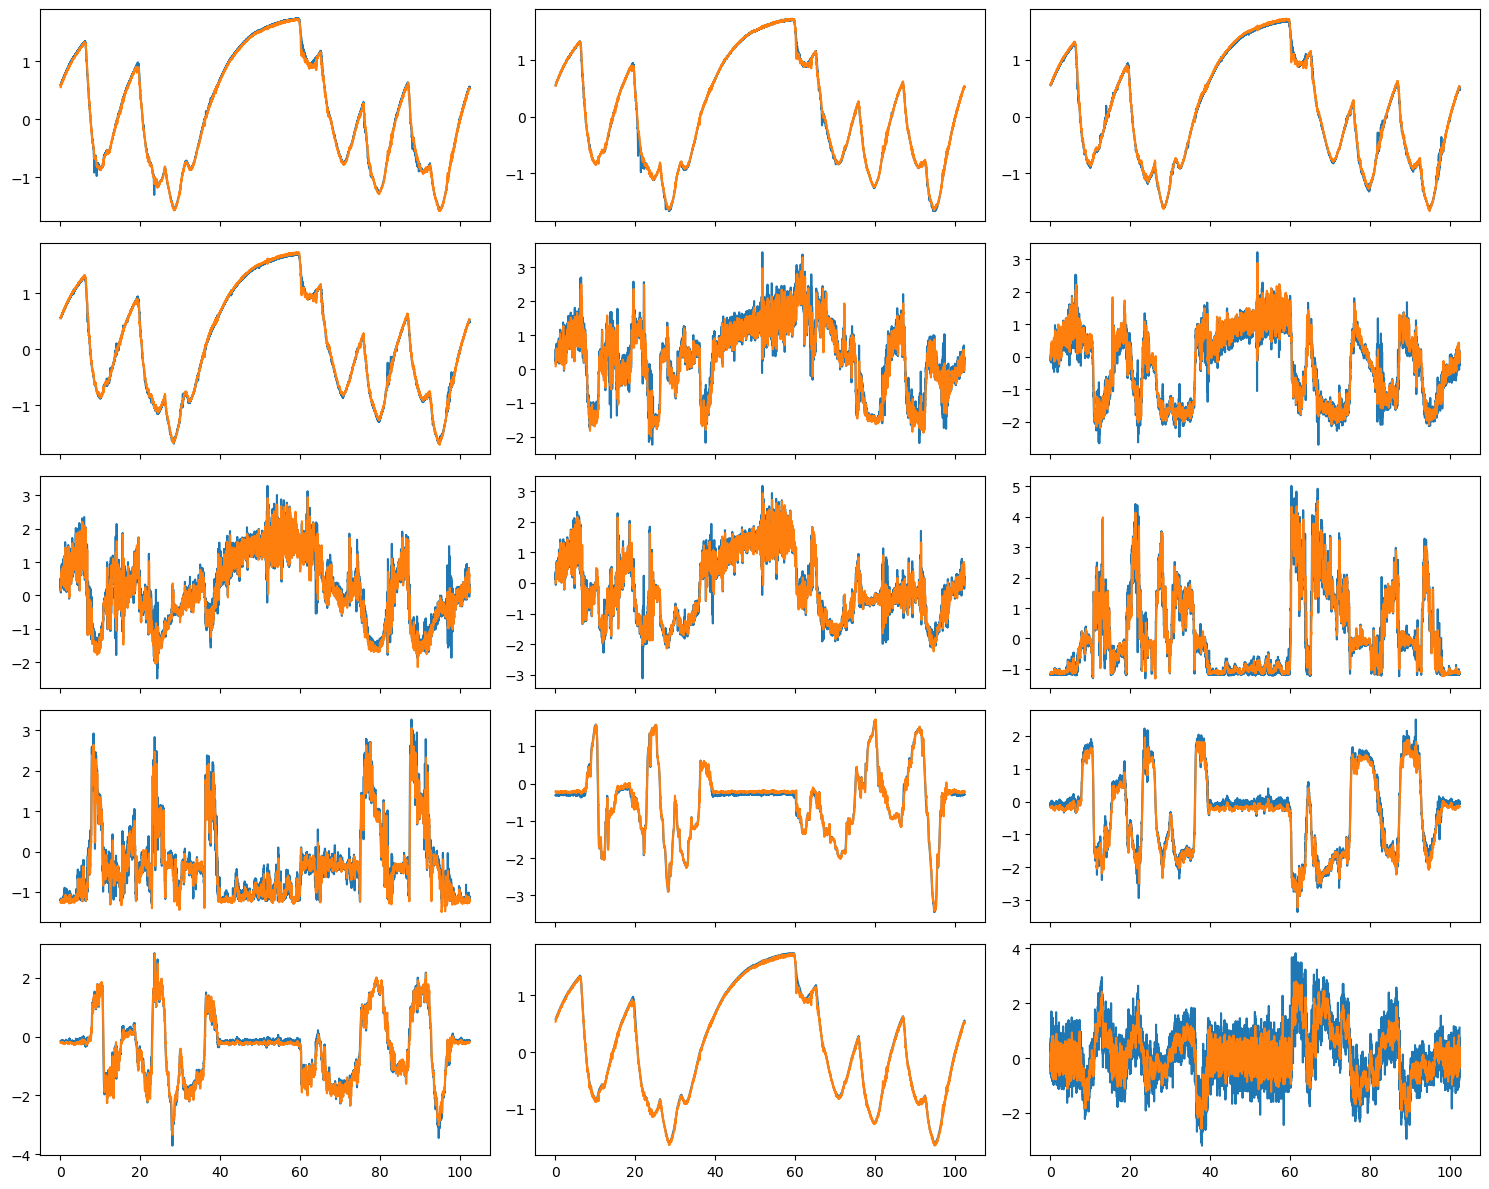

323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step


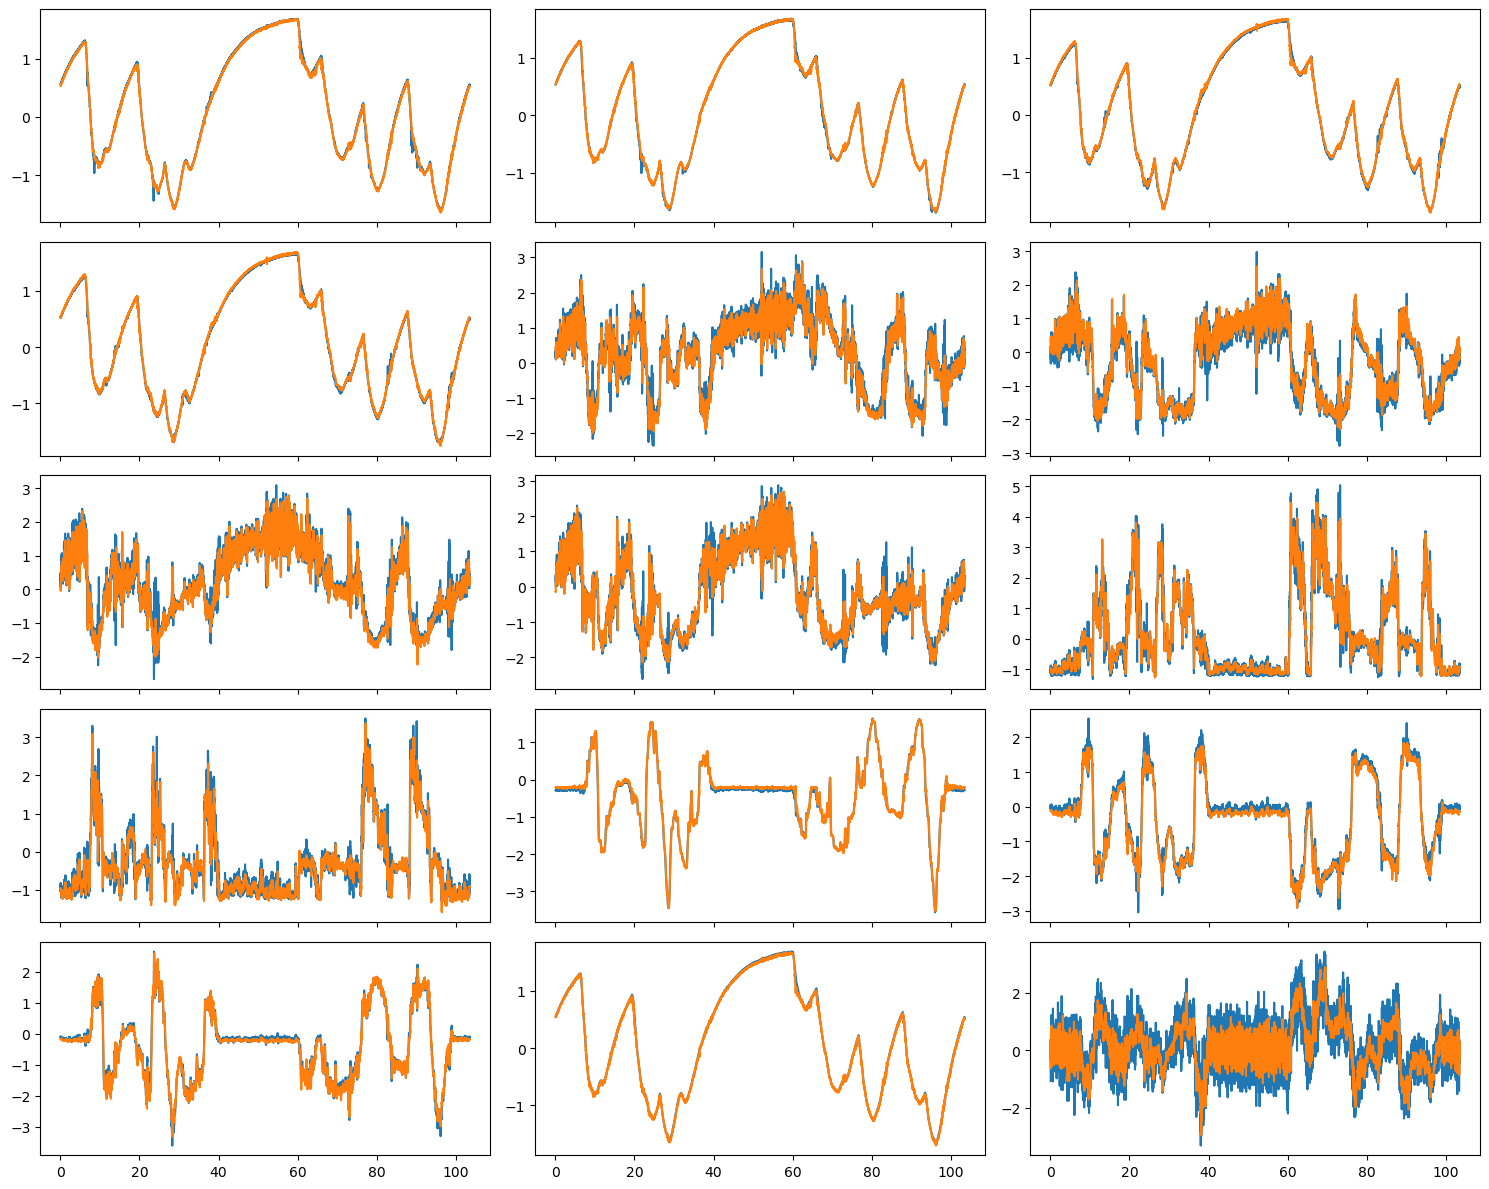

323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step


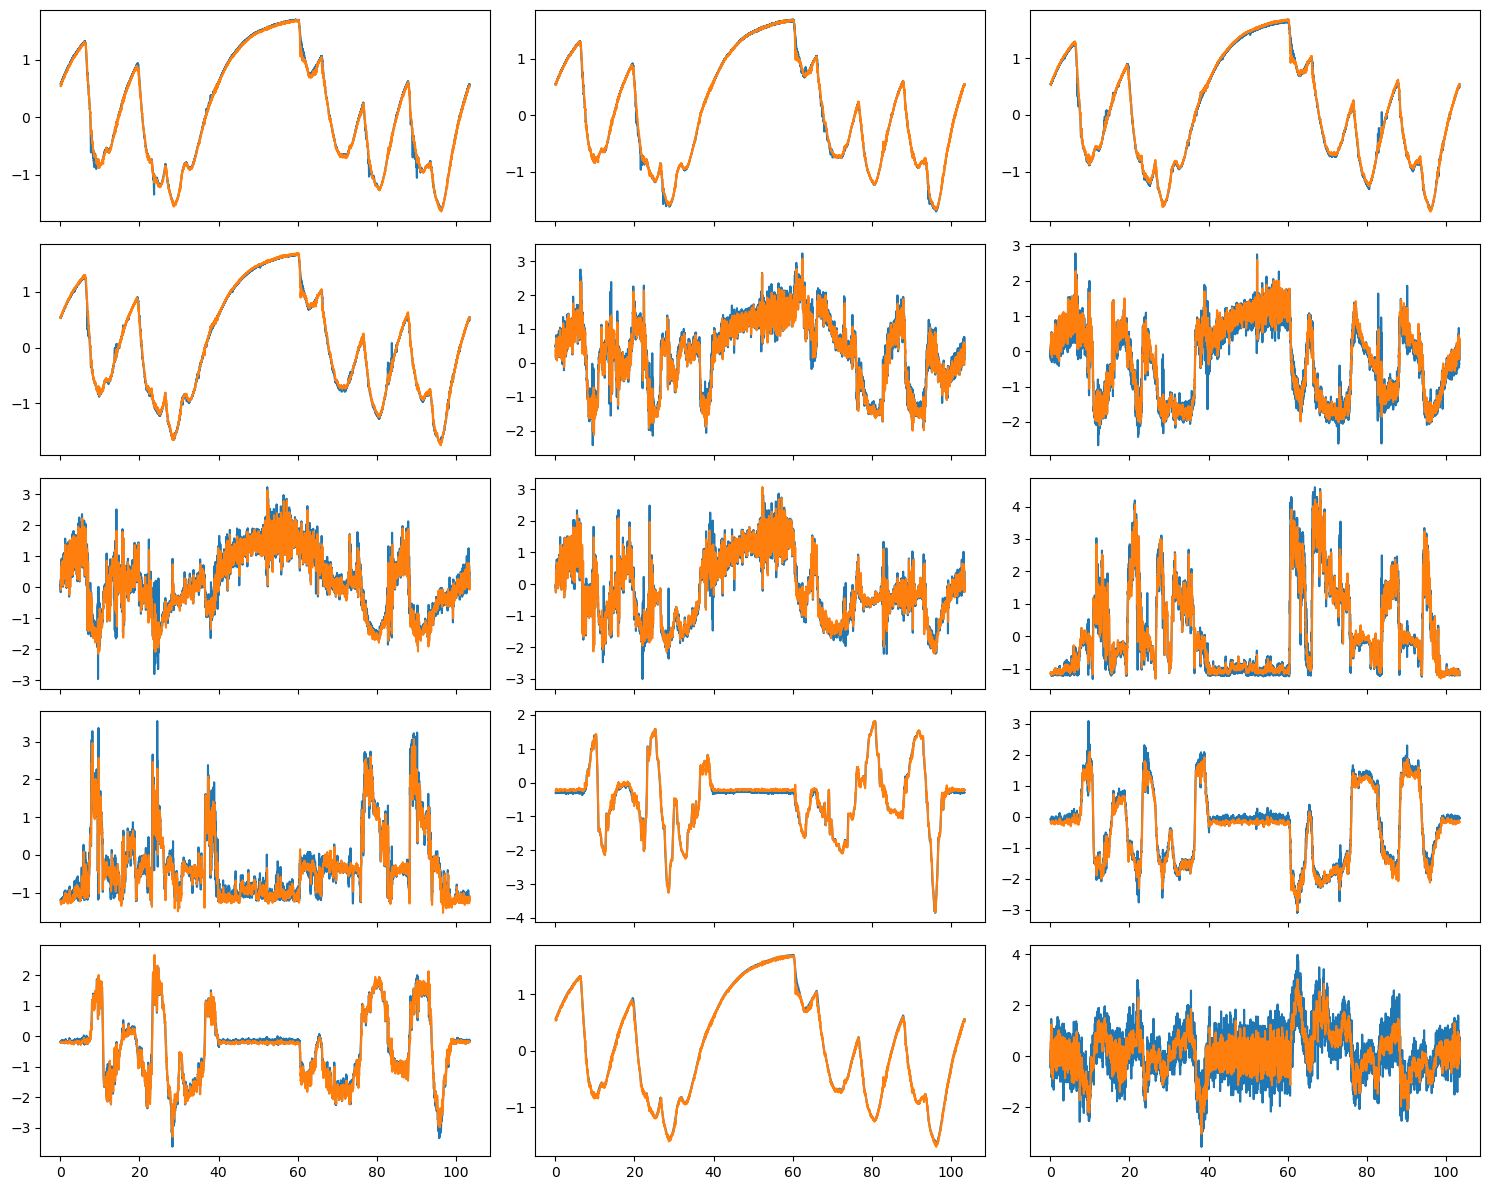

325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step


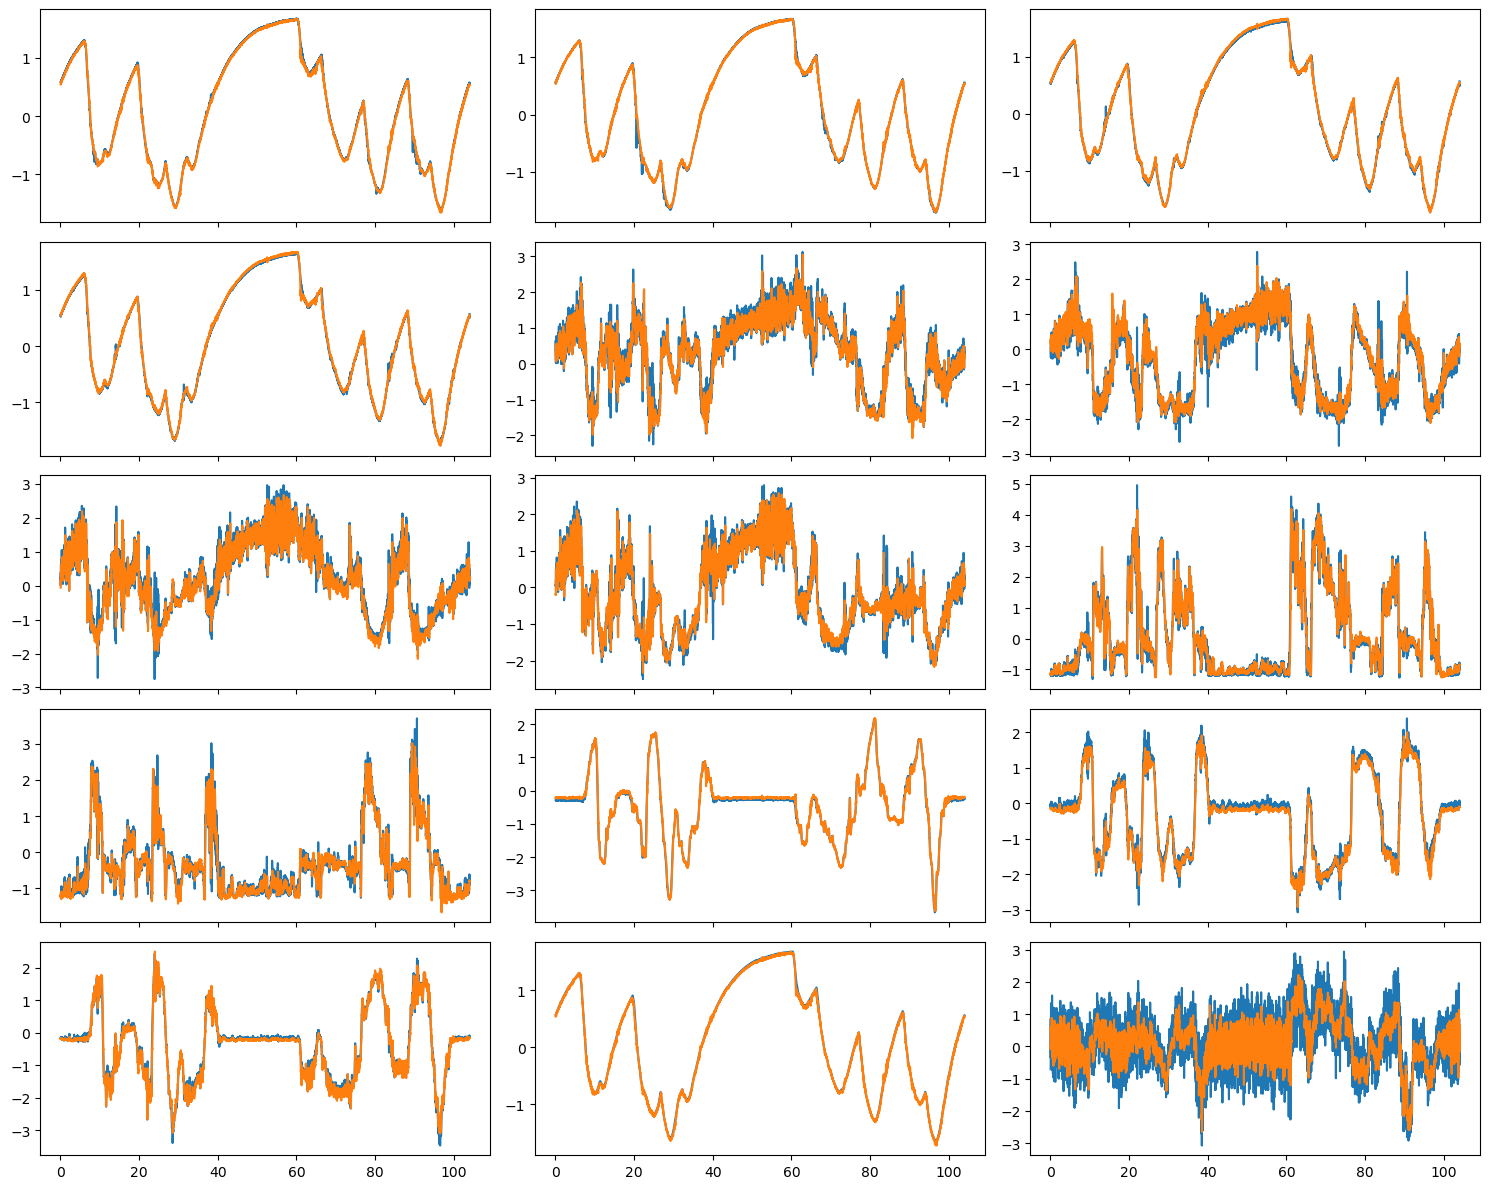

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


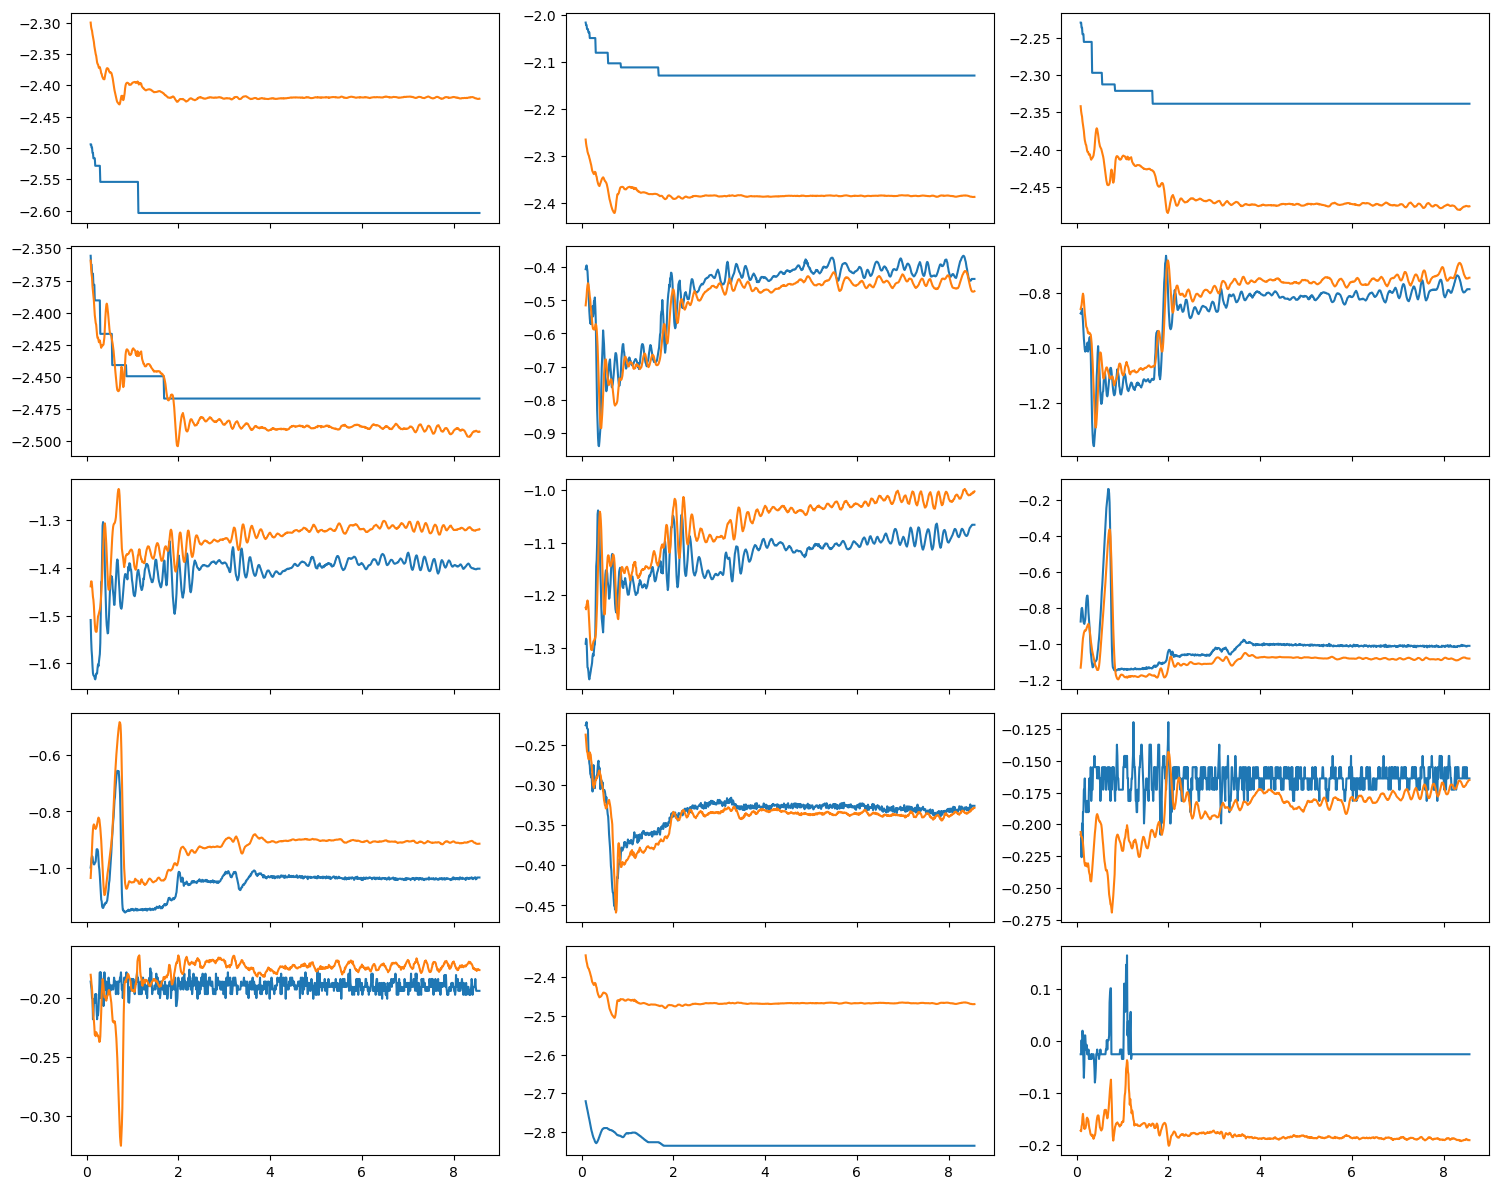

In [27]:
cols = ['nwl1', 'nwl2', 'nwl3', 'nwl4', 'fprd1', 'fprd2', 'fprd3',
       'fprd4', 'pstr1', 'pstr3', 'astrw', 'g2', 'ny', 'vcrf', 'v2']
for s in list_session2[:5]:
    df = data_dict2[s].copy()
    df = preprocessing.clean_dataframe(df)
    df[cols] = scaler_GRU.transform(df[cols])
    x_train = create_sequences(df, cols, 10)
    reconstruction = GRU.predict(x_train)
    array = reconstruction[:, 5, :]
    visualisation_plot_nparray(df.iloc[9:,:], array, cols)